# MSCA 691 — Time Series Forecasting (Automated, Structured Pipeline)

## I. Objective

This notebook loops **automatically** over **Y1, Y2, Y3, Y4** in every subsection.

## II. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Statistical
from statsmodels.tsa.arima.model import ARIMA

# Machine Learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.feature_selection import (
    VarianceThreshold, mutual_info_regression, RFE, SelectKBest)
from scipy.stats import randint, uniform

# XGBoost
from xgboost import XGBRegressor

# Support Vector Regression
from sklearn.svm import SVR
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Bayesian Optimisation
try:
    from skopt import BayesSearchCV
    from skopt.space import Real, Integer
    BAYES_AVAILABLE = True
    print('scikit-optimize detected — Bayesian Optimisation enabled.')
except ImportError:
    BAYES_AVAILABLE = False
    print('scikit-optimize not found. Install: pip install scikit-optimize')
    print('Falling back to refined Random Search for the Bayesian slot.')

# Deep Learning
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Dense, LSTM, GRU, Dropout,
    Conv1D, MaxPooling1D, Flatten, Bidirectional, Input)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K

print('All libraries loaded.')

scikit-optimize not found. Install: pip install scikit-optimize
Falling back to refined Random Search for the Bayesian slot.
All libraries loaded.


## III. Load Data

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving MSCA 691 Winter 2026 Exam - Time series data.xlsx to MSCA 691 Winter 2026 Exam - Time series data.xlsx


In [ ]:
# Load the dataset
df = pd.read_excel('MSCA 691 Winter 2026 Exam - Time series data.xlsx')
print(f'Shape: {df.shape}  |  Columns: {df.columns.tolist()}')
df.head()

Shape: (2041, 7)  |  Columns: ['Y1', 'Y2', 'Y3', 'Y4', 'Y5', 'Y6', 'Y7']


,Y1,Y2,Y3,Y4,Y5,Y6,Y7
0,51.61,4.61,0.034875,414.02,143.74,66.65,60.37
1,51.06,5.27,0.031520,430.15,151.55,67.85,61.61
2,52.24,5.72,0.037120,444.85,154.97,68.73,61.98
3,55.93,6.43,0.053289,420.82,148.59,68.01,61.49
4,67.85,6.68,0.046935,446.46,155.28,68.48,61.73


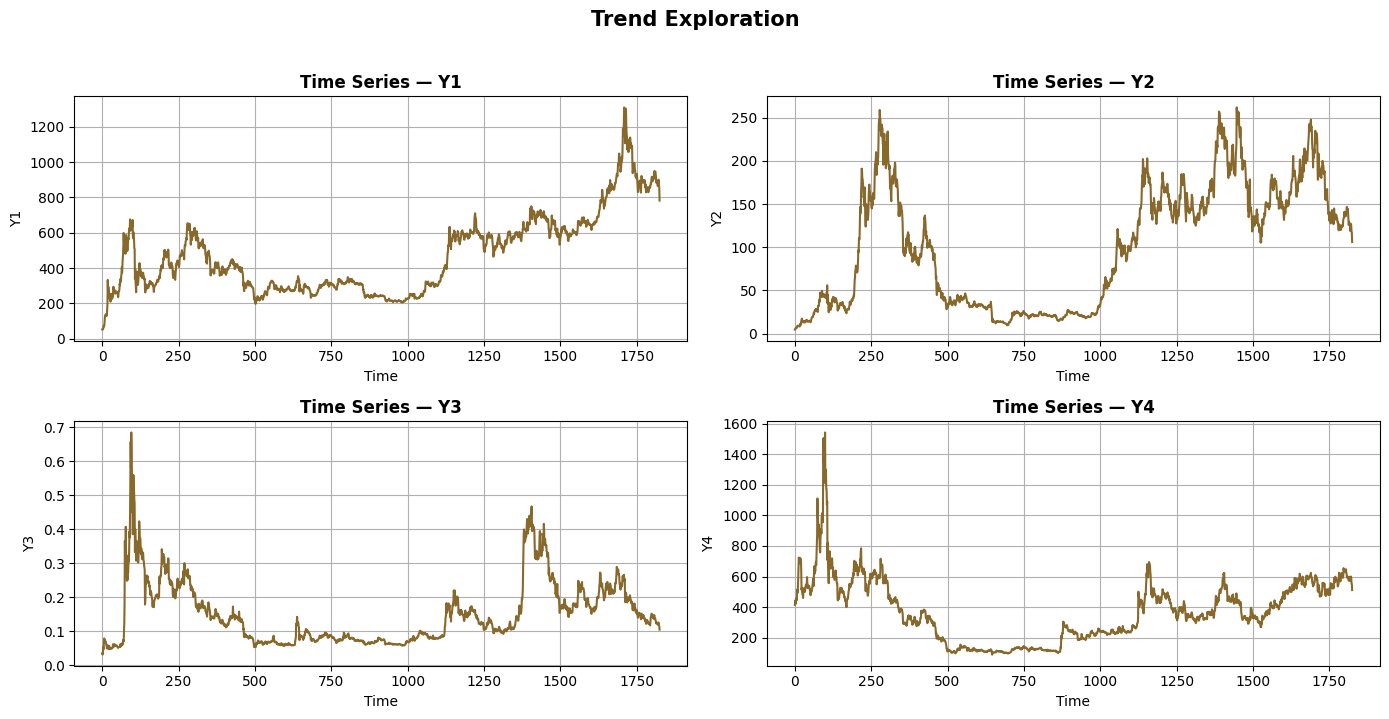

In [ ]:
SELECTED    = ['Y1', 'Y2', 'Y3', 'Y4']
WINDOW_SIZE = 30
TRAIN_RATIO = 0.8
N_CV_SPLITS = 5
tscv        = TimeSeriesSplit(n_splits=N_CV_SPLITS)

# Global stores — populated section by section
ALL_RESULTS  = {col: [] for col in SELECTED}   # metric dicts
ALL_PREDS    = {col: {}  for col in SELECTED}   # prediction arrays
DL_HIST      = {col: {}  for col in SELECTED}   # keras History objects

# Per-series data containers — filled in Section IV and reused throughout
DATA = {}   # DATA[col] = dict with X_tr, X_te, y_tr, y_te, X_tr_dl, X_te_dl, ...

# Explore the selected series
fig, axes = plt.subplots(2, 2, figsize=(14, 7))
for ax, col in zip(axes.ravel(), SELECTED):
    ax.plot(df[col], color='#89682c')
    ax.set_title(f'Time Series — {col}', fontweight='bold')
    ax.set_xlabel('Time'); ax.set_ylabel(col); ax.grid(True)
plt.suptitle('Trend Exploration', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

## IV. Helper Functions & Feature Selection

### 4.1 Metrics

In [ ]:
def calculate_metrics(y_true, y_pred, name):
    """Compute RMSE, MAE, MAD, MAPE and return as a dict."""
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mad  = np.mean(np.abs(y_true - y_pred))
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    return {'Model': name, 'RMSE': round(rmse,4),
            'MAE': round(mae,4), 'MAD': round(mad,4), 'MAPE': round(mape,2)}


def store(col, y_true, y_pred, label):
    """Compute metrics, store predictions, and print a one-liner summary."""
    r = calculate_metrics(y_true, y_pred, label)
    r['Series'] = col
    ALL_RESULTS[col].append(r)
    ALL_PREDS[col][label] = y_pred
    print(f'  [{col}] {label:45s}  RMSE={r["RMSE"]:.4f}  '
          f'MAE={r["MAE"]:.4f}  MAPE={r["MAPE"]:.2f}%')

print('Metrics helpers defined.')

Metrics helpers defined.


### 4.2 Feature Selection

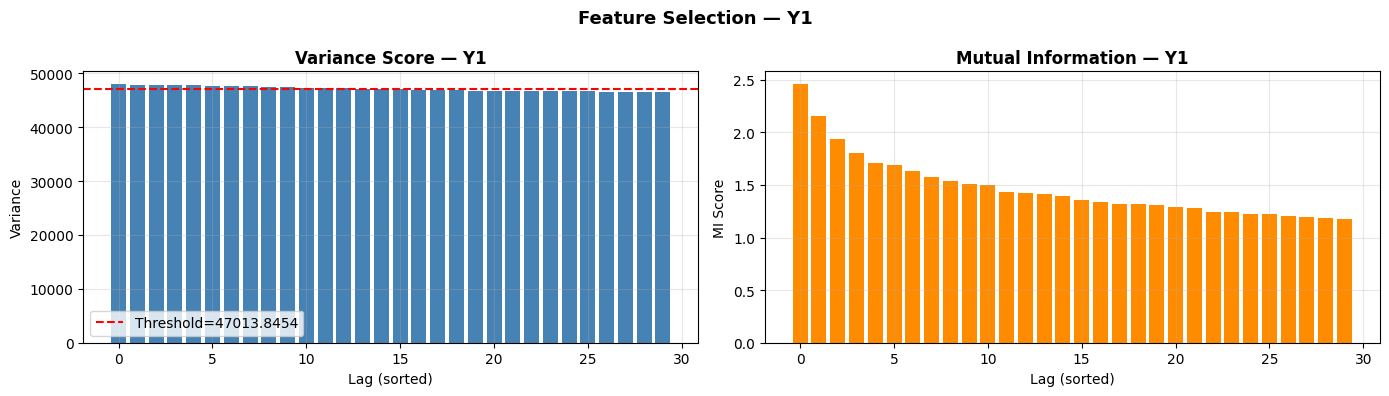

Y1: Variance=15,  MI=15,  RFE=15 (used for ML)


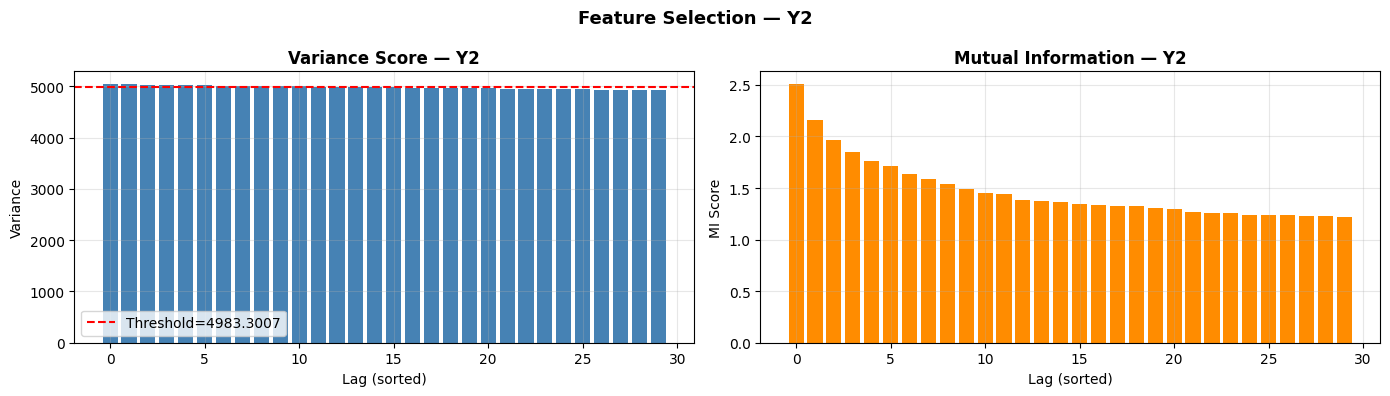

Y2: Variance=15,  MI=15,  RFE=15 (used for ML)


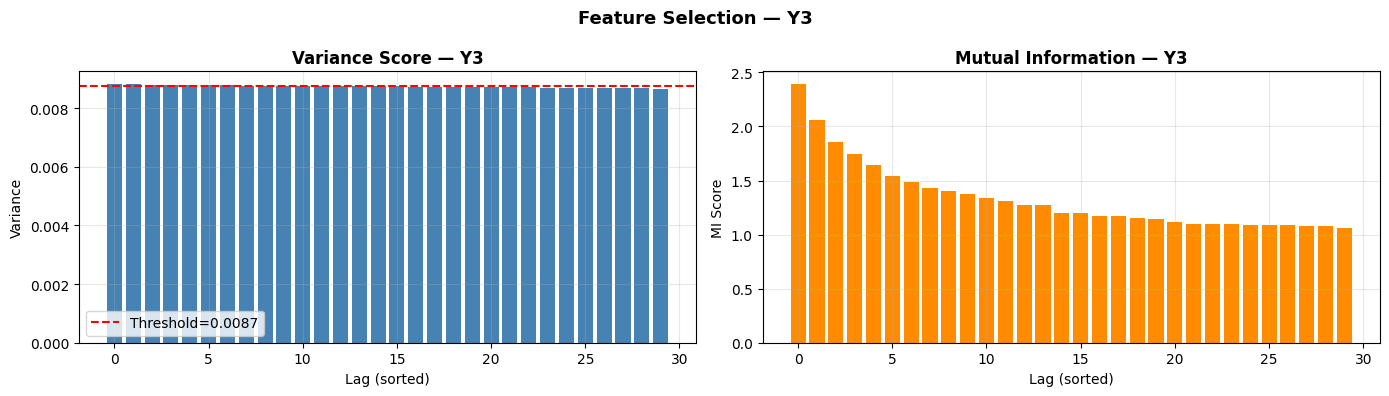

Y3: Variance=15,  MI=15,  RFE=15 (used for ML)


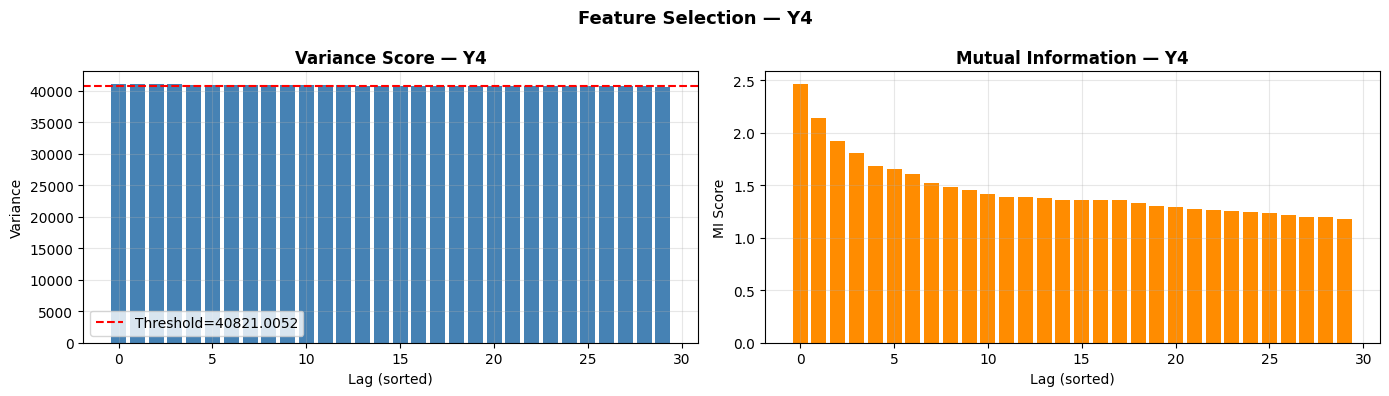

Y4: Variance=15,  MI=15,  RFE=15 (used for ML)

Feature selection and data preparation complete for all series.


In [ ]:
for target_col in SELECTED:
    series = df[target_col].dropna().reset_index(drop=True)

    # Rolling window
    X_all, y_all = [], []
    for i in range(WINDOW_SIZE, len(series)):
        X_all.append(series.values[i - WINDOW_SIZE:i])
        y_all.append(series.values[i])
    X_all = np.array(X_all); y_all = np.array(y_all)

    k = max(5, WINDOW_SIZE // 2)

    # 1. Variance Score
    variances = np.var(X_all, axis=0)
    sel_var   = VarianceThreshold(threshold=np.median(variances))
    sel_var.fit(X_all)

    # 2. Mutual Information
    mi_scores = mutual_info_regression(X_all, y_all, random_state=42)
    sel_mi    = SelectKBest(mutual_info_regression, k=k)
    sel_mi.fit(X_all, y_all)

    # 3. RFE
    sel_rfe = RFE(RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
                  n_features_to_select=k, step=1)
    X_rfe = sel_rfe.fit_transform(X_all, y_all)

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sv = np.argsort(variances)[::-1]
    axes[0].bar(range(WINDOW_SIZE), variances[sv], color='steelblue')
    axes[0].axhline(np.median(variances), color='red', linestyle='--',
                    label=f'Threshold={np.median(variances):.4f}')
    axes[0].set_title(f'Variance Score — {target_col}', fontweight='bold')
    axes[0].set_xlabel('Lag (sorted)'); axes[0].set_ylabel('Variance')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    sm = np.argsort(mi_scores)[::-1]
    axes[1].bar(range(WINDOW_SIZE), mi_scores[sm], color='darkorange')
    axes[1].set_title(f'Mutual Information — {target_col}', fontweight='bold')
    axes[1].set_xlabel('Lag (sorted)'); axes[1].set_ylabel('MI Score')
    axes[1].grid(True, alpha=0.3)
    plt.suptitle(f'Feature Selection — {target_col}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    print(f'{target_col}: Variance={sel_var.get_support().sum()},  '
          f'MI={sel_mi.get_support().sum()},  '
          f'RFE={sel_rfe.support_.sum()} (used for ML)')

    # Train/test split
    sp = int(len(X_rfe) * TRAIN_RATIO)
    raw_sp = int(len(series) * TRAIN_RATIO)
    DATA[target_col] = dict(
        X_tr=X_rfe[:sp],  X_te=X_rfe[sp:],
        y_tr=y_all[:sp],  y_te=y_all[sp:],
        X_tr_dl=X_all[:sp].reshape(-1, WINDOW_SIZE, 1),
        X_te_dl=X_all[sp:].reshape(-1, WINDOW_SIZE, 1),
        train_s=series.iloc[:raw_sp],
        test_s=series.iloc[raw_sp:]
    )
    ALL_PREDS[target_col]['True Value'] = y_all[sp:]

print('\nFeature selection and data preparation complete for all series.')

## V. Model 1 — ARIMA (Statistical Baseline)

ARIMA(5,1,0) is a classical statistical model that works directly on the raw time series.
It serves as a **baseline** to benchmark all machine learning and deep learning models against.

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    preds, history = [], list(d['train_s'])
    for t in range(len(d['test_s'])):
        fit = ARIMA(history, order=(5, 1, 0)).fit()
        preds.append(fit.forecast()[0])
        history.append(d['test_s'].iloc[t])
    arima_pred = np.array(preds)
    amin = min(len(d['y_te']), len(arima_pred))
    pad  = np.full(max(0, len(d['y_te']) - amin), np.nan)
    store(target_col, d['test_s'].values[:amin], arima_pred[:amin], 'ARIMA (Baseline)')
    ALL_PREDS[target_col]['ARIMA (Baseline)'] = np.concatenate([arima_pred[:amin], pad])

print('ARIMA done.')

  [Y1] ARIMA (Baseline)                               RMSE=25.3567  MAE=15.7688  MAPE=1.91%
  [Y2] ARIMA (Baseline)                               RMSE=7.3355  MAE=5.2891  MAPE=3.23%


/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood op

  [Y3] ARIMA (Baseline)                               RMSE=0.0104  MAE=0.0074  MAPE=3.75%
  [Y4] ARIMA (Baseline)                               RMSE=17.5980  MAE=13.0730  MAPE=2.79%
ARIMA done.


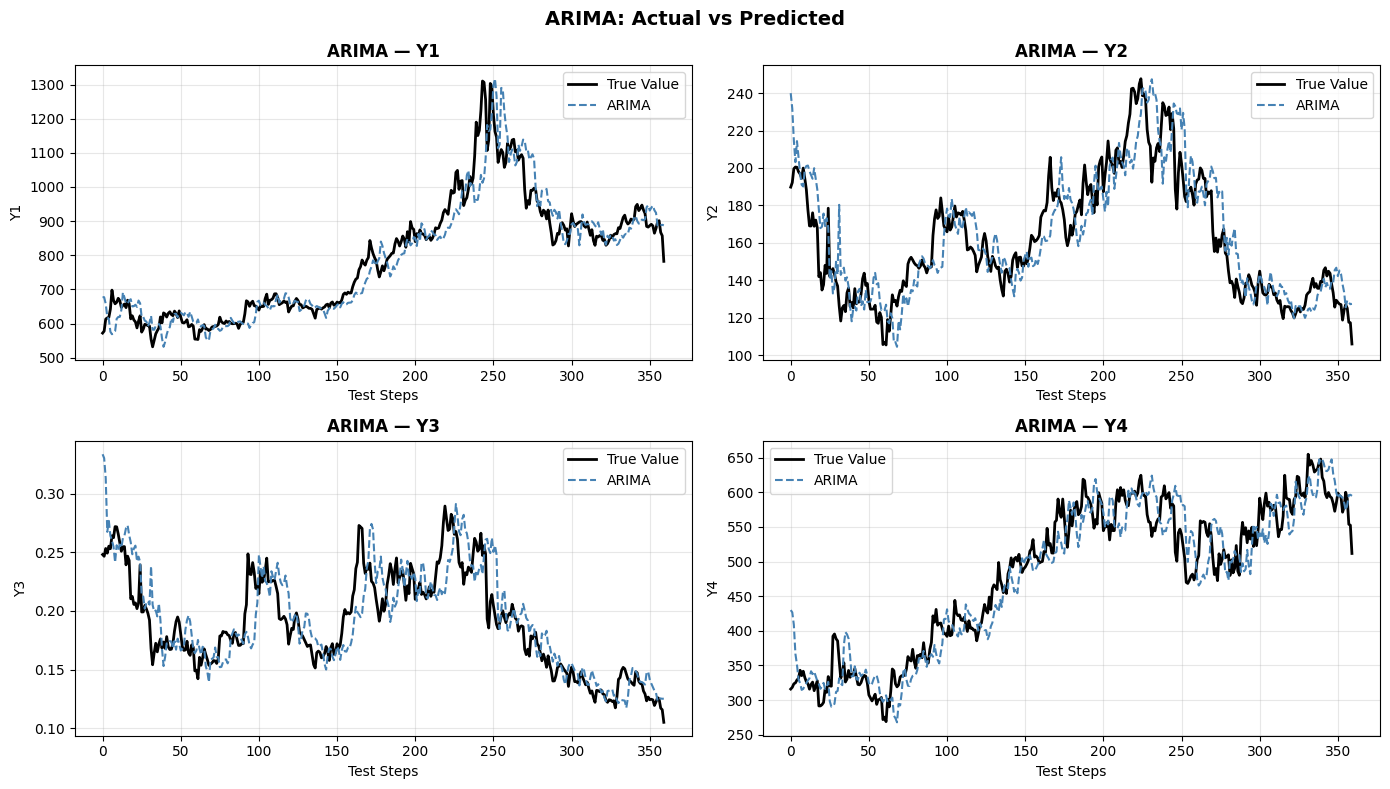

In [ ]:
# Actual vs Predicted — ARIMA
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]
    p = ALL_PREDS[col]
    ax.plot(d['y_te'],               label='True Value', color='black', linewidth=2)
    ax.plot(p['ARIMA (Baseline)'],   label='ARIMA',      color='steelblue', linestyle='--')
    ax.set_title(f'ARIMA — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('ARIMA: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## VI. Model 2 — Random Forest

Random Forest is an ensemble of decision trees that captures **nonlinear** relationships
in the lag-feature space produced by the rolling window.

- **Baseline**: default hyperparameters (`n_estimators=100`)
- **Optimized**: Grid Search over `n_estimators`, `max_depth`, `min_samples_split`
  with 5-fold `TimeSeriesSplit` cross-validation

### 6.1 Random Forest — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    m = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    m.fit(d['X_tr'], d['y_tr'])
    store(target_col, d['y_te'], m.predict(d['X_te']), 'RF (Baseline)')

print('RF Baseline done.')

  [Y1] RF (Baseline)                                  RMSE=179.7411  MAE=121.5827  MAPE=12.82%
  [Y2] RF (Baseline)                                  RMSE=7.8518  MAE=5.7201  MAPE=3.60%
  [Y3] RF (Baseline)                                  RMSE=0.0114  MAE=0.0080  MAPE=4.13%
  [Y4] RF (Baseline)                                  RMSE=19.7594  MAE=15.0481  MAPE=3.17%
RF Baseline done.


### 6.2 Random Forest — Grid Search Optimized

In [ ]:
rf_param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5]
}

for target_col in SELECTED:
    d = DATA[target_col]
    gs = GridSearchCV(
        RandomForestRegressor(random_state=42, n_jobs=-1),
        rf_param_grid, cv=tscv,
        scoring='neg_root_mean_squared_error',
        n_jobs=-1, verbose=0)
    gs.fit(d['X_tr'], d['y_tr'])
    print(f'  [{target_col}] Best params: {gs.best_params_}  '
          f'CV-RMSE={-gs.best_score_:.4f}')
    store(target_col, d['y_te'],
          gs.best_estimator_.predict(d['X_te']), 'RF (Grid Search)')

print('RF Grid Search done.')

  [Y1] Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}  CV-RMSE=17.1367
  [Y1] RF (Grid Search)                               RMSE=176.6608  MAE=118.4123  MAPE=12.44%
  [Y2] Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}  CV-RMSE=9.1780
  [Y2] RF (Grid Search)                               RMSE=7.7961  MAE=5.6876  MAPE=3.58%
  [Y3] Best params: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}  CV-RMSE=0.0164
  [Y3] RF (Grid Search)                               RMSE=0.0114  MAE=0.0080  MAPE=4.12%
  [Y4] Best params: {'max_depth': 5, 'min_samples_split': 2, 'n_estimators': 200}  CV-RMSE=43.7898
  [Y4] RF (Grid Search)                               RMSE=18.8379  MAE=14.1037  MAPE=2.97%
RF Grid Search done.


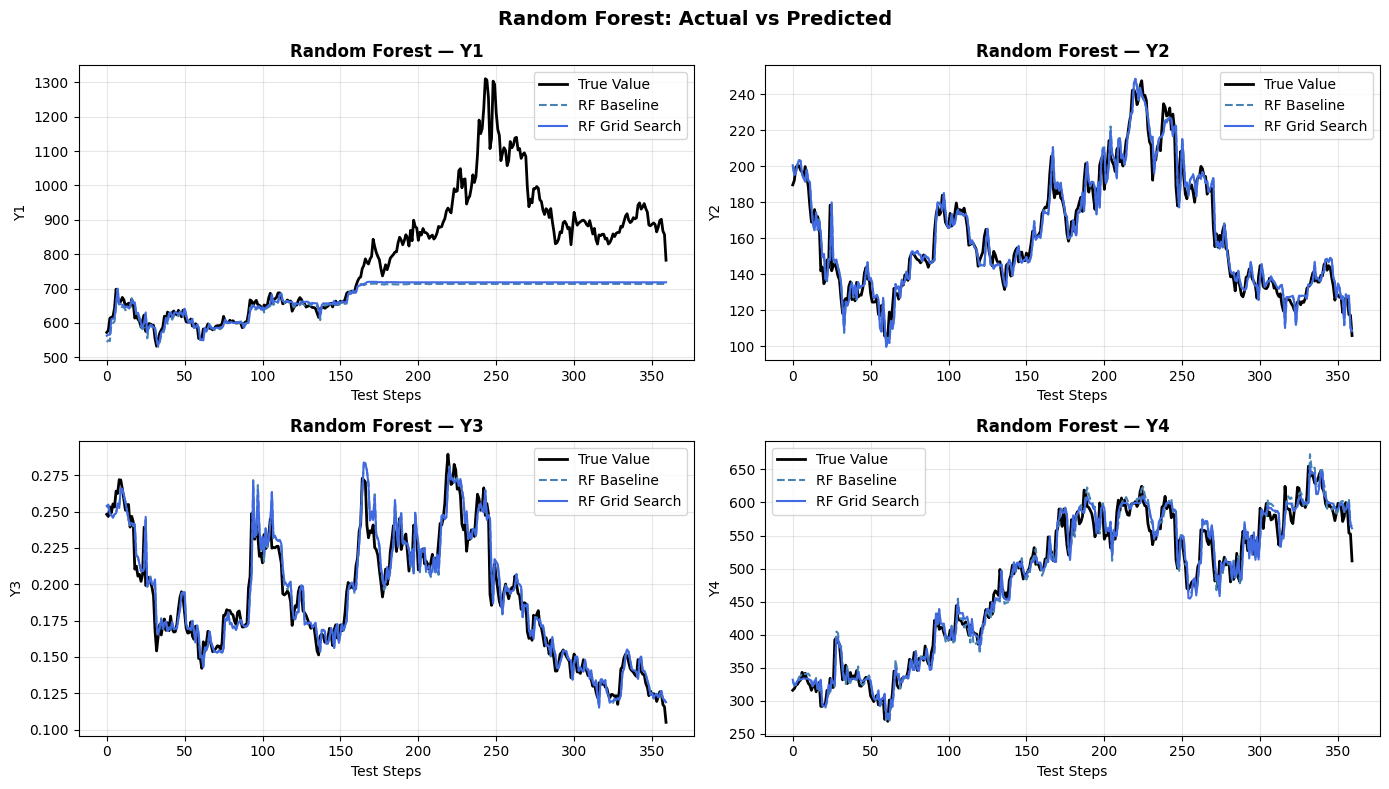

In [ ]:
# Actual vs Predicted — Random Forest (both variants)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],             color='black',     linewidth=2,   label='True Value')
    ax.plot(p['RF (Baseline)'],    color='steelblue', linestyle='--',label='RF Baseline')
    ax.plot(p['RF (Grid Search)'], color='royalblue', linestyle='-', label='RF Grid Search')
    ax.set_title(f'Random Forest — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Random Forest: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## VII. Model 3 — XGBoost

XGBoost is a gradient-boosted decision tree model well-suited to tabular, lag-structured data.

- **Baseline**: default parameters (`n_estimators=200`, `learning_rate=0.05`, `max_depth=4`)
- **Optimized (Random Search)**: 30 random combinations sampled from bounded distributions
  with 5-fold `TimeSeriesSplit` CV
- **Optimized (Bayesian Opt.)**: Gaussian Process surrogate + Expected Improvement
  acquisition function directs the search — much fewer evaluations needed than Grid Search

### 7.1 XGBoost — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    m = XGBRegressor(n_estimators=200, learning_rate=0.05,
                     max_depth=4, random_state=42, verbosity=0)
    m.fit(d['X_tr'], d['y_tr'])
    store(target_col, d['y_te'], m.predict(d['X_te']), 'XGBoost (Baseline)')

print('XGBoost Baseline done.')

  [Y1] XGBoost (Baseline)                             RMSE=182.4223  MAE=124.3672  MAPE=13.17%
  [Y2] XGBoost (Baseline)                             RMSE=7.8141  MAE=5.8349  MAPE=3.66%
  [Y3] XGBoost (Baseline)                             RMSE=0.0116  MAE=0.0079  MAPE=4.06%
  [Y4] XGBoost (Baseline)                             RMSE=20.2207  MAE=15.6075  MAPE=3.25%
XGBoost Baseline done.


### 7.2 XGBoost — Random Search Optimized

In [ ]:
xgb_dist = {
    'n_estimators'     : randint(100, 500),
    'learning_rate'    : uniform(0.01, 0.2),
    'max_depth'        : randint(3, 8),
    'subsample'        : uniform(0.6, 0.4),
    'colsample_bytree' : uniform(0.6, 0.4),
    'reg_alpha'        : uniform(0, 1),
    'reg_lambda'       : uniform(0.5, 2)
}

for target_col in SELECTED:
    d = DATA[target_col]
    rs = RandomizedSearchCV(
        XGBRegressor(random_state=42, verbosity=0),
        xgb_dist, n_iter=30, cv=tscv,
        scoring='neg_root_mean_squared_error',
        random_state=42, n_jobs=-1, verbose=0)
    rs.fit(d['X_tr'], d['y_tr'])
    print(f'  [{target_col}] CV-RMSE={-rs.best_score_:.4f}')
    store(target_col, d['y_te'],
          rs.best_estimator_.predict(d['X_te']), 'XGBoost (Random Search)')

print('XGBoost Random Search done.')

  [Y1] CV-RMSE=23.5225
  [Y1] XGBoost (Random Search)                        RMSE=184.9610  MAE=126.9558  MAPE=13.48%
  [Y2] CV-RMSE=11.0044
  [Y2] XGBoost (Random Search)                        RMSE=8.0655  MAE=6.0334  MAPE=3.75%
  [Y3] CV-RMSE=0.0166
  [Y3] XGBoost (Random Search)                        RMSE=0.0116  MAE=0.0083  MAPE=4.29%


### 7.3 XGBoost — Bayesian Optimization

In [ ]:
BO_LABEL = 'XGBoost (Bayesian Opt.)' if BAYES_AVAILABLE else 'XGBoost (Bayes Fallback)'

for target_col in SELECTED:
    d = DATA[target_col]
    if BAYES_AVAILABLE:
        from skopt import BayesSearchCV
        from skopt.space import Real, Integer
        bs = BayesSearchCV(
            XGBRegressor(random_state=42, verbosity=0),
            {'n_estimators'    : Integer(100, 500),
             'learning_rate'   : Real(0.01, 0.3, prior='log-uniform'),
             'max_depth'       : Integer(3, 8),
             'subsample'       : Real(0.5, 1.0),
             'colsample_bytree': Real(0.5, 1.0),
             'reg_alpha'       : Real(1e-3, 1.0, prior='log-uniform'),
             'reg_lambda'      : Real(0.5, 3.0)},
            n_iter=30, cv=tscv,
            scoring='neg_root_mean_squared_error',
            random_state=42, n_jobs=-1, verbose=0)
        bs.fit(d['X_tr'], d['y_tr'])
        print(f'  [{target_col}] CV-RMSE={-bs.best_score_:.4f}')
        pred = bs.best_estimator_.predict(d['X_te'])
    else:
        rs2 = RandomizedSearchCV(
            XGBRegressor(random_state=0, verbosity=0),
            {'n_estimators'    : randint(150, 450),
             'learning_rate'   : uniform(0.02, 0.15),
             'max_depth'       : randint(3, 7),
             'subsample'       : uniform(0.65, 0.35),
             'colsample_bytree': uniform(0.65, 0.35)},
            n_iter=40, cv=tscv,
            scoring='neg_root_mean_squared_error',
            random_state=0, n_jobs=-1, verbose=0)
        rs2.fit(d['X_tr'], d['y_tr'])
        print(f'  [{target_col}] CV-RMSE={-rs2.best_score_:.4f}')
        pred = rs2.best_estimator_.predict(d['X_te'])
    store(target_col, d['y_te'], pred, BO_LABEL)

print('XGBoost Bayesian Opt. done.')

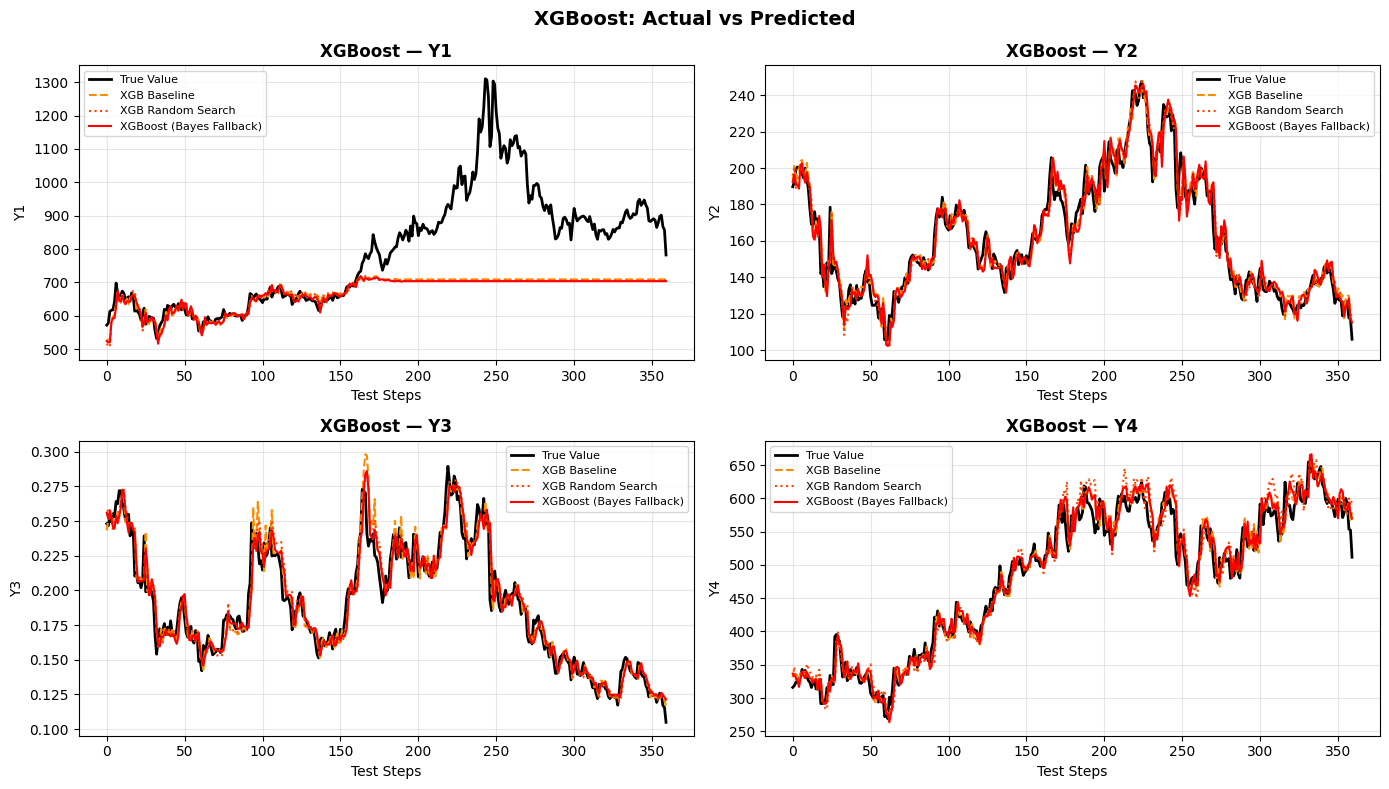

In [ ]:
# Actual vs Predicted — XGBoost (all three variants)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],                 color='black',     linewidth=2,    label='True Value')
    ax.plot(p['XGBoost (Baseline)'],   color='darkorange', linestyle='--',label='XGB Baseline')
    ax.plot(p['XGBoost (Random Search)'],color='orangered',linestyle=':',  label='XGB Random Search')
    ax.plot(p[BO_LABEL],               color='red',        linestyle='-',  label=BO_LABEL)
    ax.set_title(f'XGBoost — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.suptitle('XGBoost: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## VIII. Model 4 — LSTM

Long Short-Term Memory networks learn temporal dependencies via gated memory cells.
They use the full 30-lag window reshaped into a 3D sequence tensor.

- **Baseline**: single LSTM layer (32 units), 50 epochs, no early stopping
- **Optimized**: stacked LSTM layers (64 → 32 units) + Dropout (0.2) + Early Stopping
  with `patience=10` on validation loss, up to 100 epochs

### 8.1 LSTM — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        LSTM(32, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=50, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'LSTM (Baseline)')
    DL_HIST[target_col]['LSTM_base'] = h

print('LSTM Baseline done.')

### 8.2 LSTM — Optimized (Stacked + Dropout + Early Stopping)

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        LSTM(64, activation='tanh', return_sequences=True,
             input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        LSTM(32, activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=100, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'LSTM (Optimized)')
    DL_HIST[target_col]['LSTM_opt'] = h

print('LSTM Optimized done.')

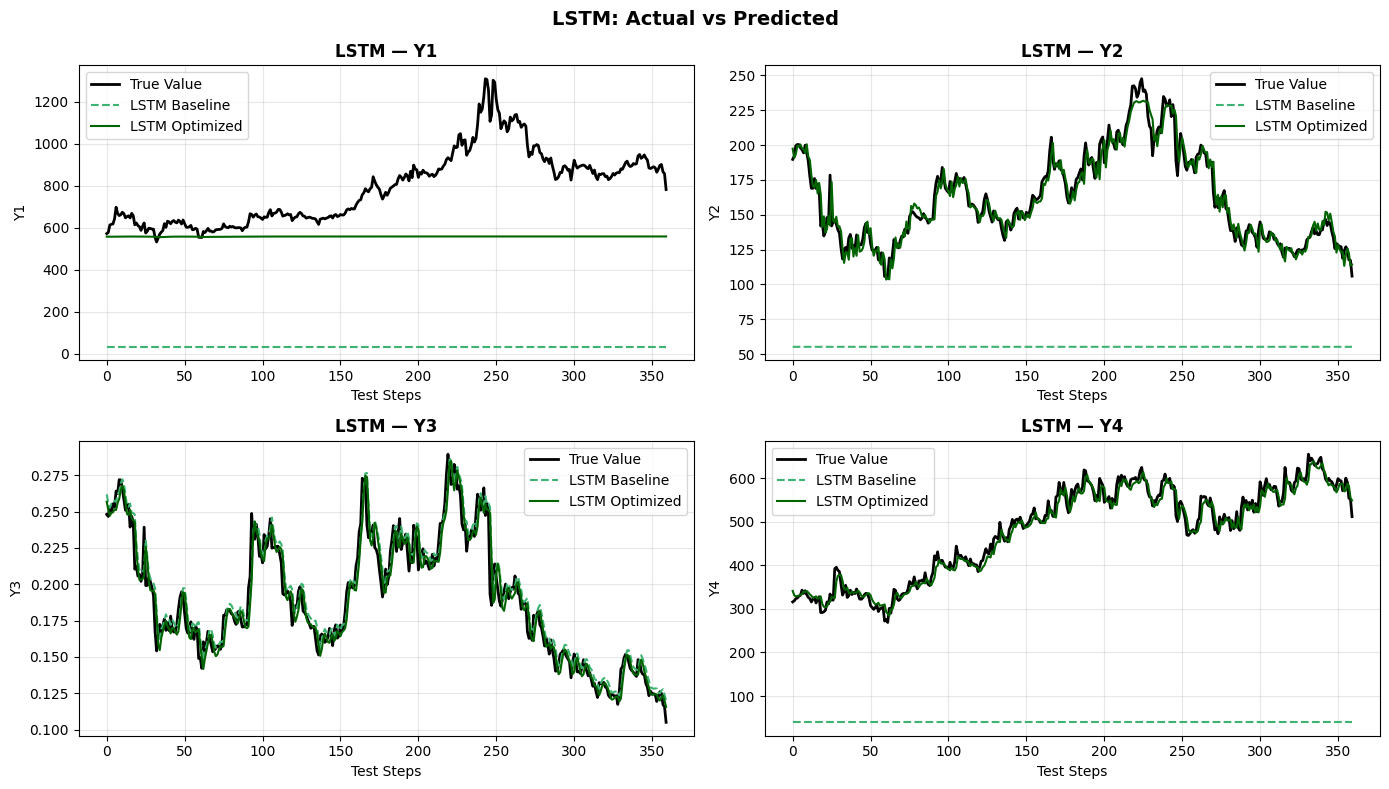

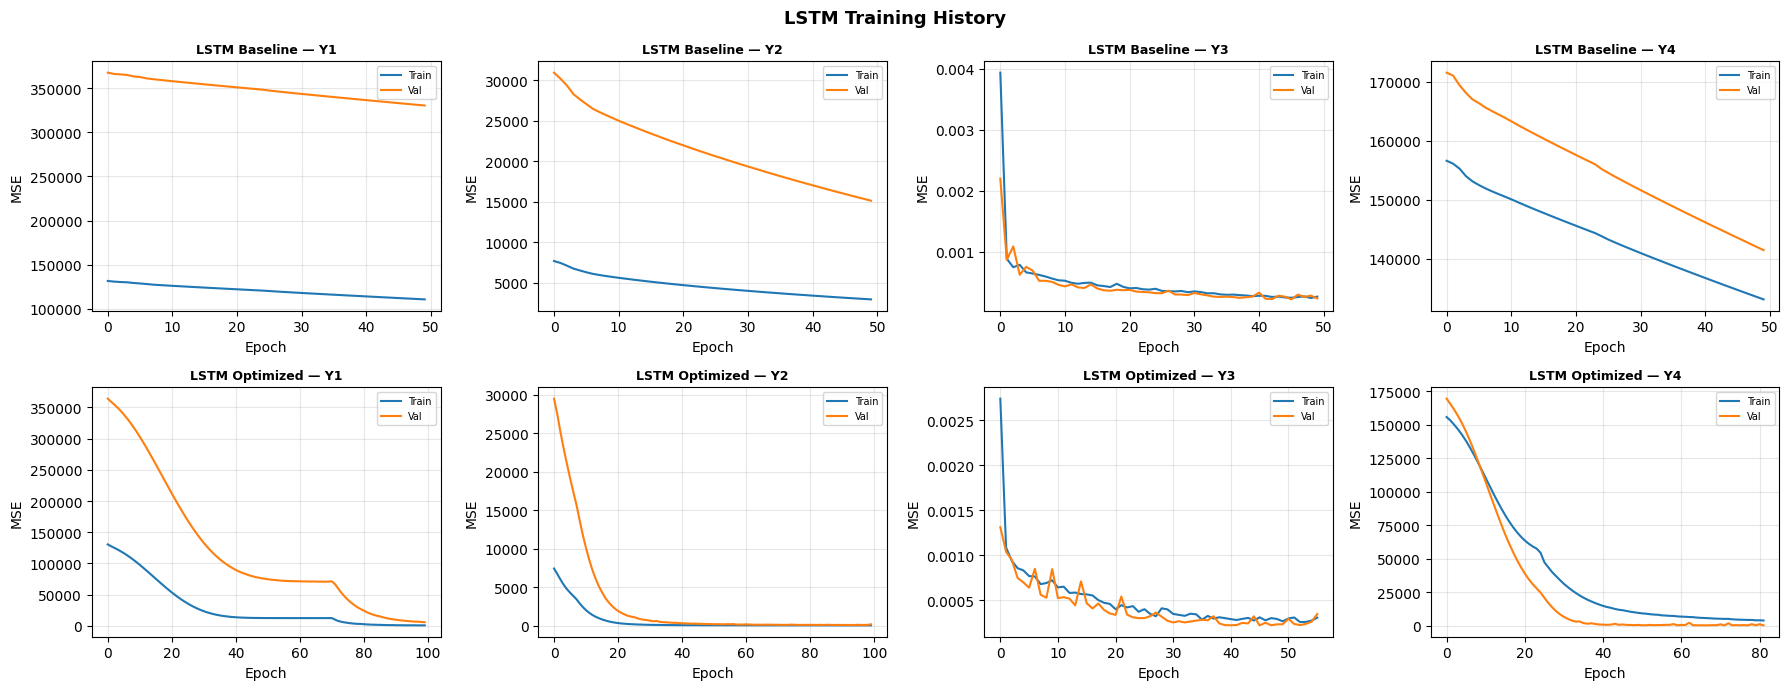

In [ ]:
# Actual vs Predicted — LSTM
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],              color='black',       linewidth=2,    label='True Value')
    ax.plot(p['LSTM (Baseline)'],   color='mediumseagreen', linestyle='--',label='LSTM Baseline')
    ax.plot(p['LSTM (Optimized)'],  color='darkgreen',   linestyle='-',  label='LSTM Optimized')
    ax.set_title(f'LSTM — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('LSTM: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Training loss
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('LSTM_base','Baseline'), ('LSTM_opt','Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'LSTM {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('LSTM Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## IX. Model 5 — GRU

Gated Recurrent Units are a lighter alternative to LSTM with fewer parameters.
They often converge faster while matching LSTM accuracy on shorter sequences.

- **Baseline**: single GRU layer (32 units), 50 epochs, no early stopping
- **Optimized**: stacked GRU layers (64 → 32 units) + Dropout (0.2) + Early Stopping
  with `patience=10` on validation loss, up to 100 epochs

### 9.1 GRU — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        GRU(32, activation='tanh', input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=50, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'GRU (Baseline)')
    DL_HIST[target_col]['GRU_base'] = h

print('GRU Baseline done.')

  [Y1] stopped at epoch 50
  [Y1] GRU (Baseline)                                 RMSE=758.8031  MAE=738.9694  MAPE=93.02%
  [Y2] stopped at epoch 50
  [Y2] GRU (Baseline)                                 RMSE=108.0844  MAE=103.2238  MAPE=62.47%
  [Y3] stopped at epoch 44
  [Y3] GRU (Baseline)                                 RMSE=0.0104  MAE=0.0075  MAPE=3.90%


### 9.2 GRU — Optimized (Stacked + Dropout + Early Stopping)

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        GRU(64, activation='tanh', return_sequences=True,
            input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        GRU(32, activation='tanh'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=100, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'GRU (Optimized)')
    DL_HIST[target_col]['GRU_opt'] = h

print('GRU Optimized done.')

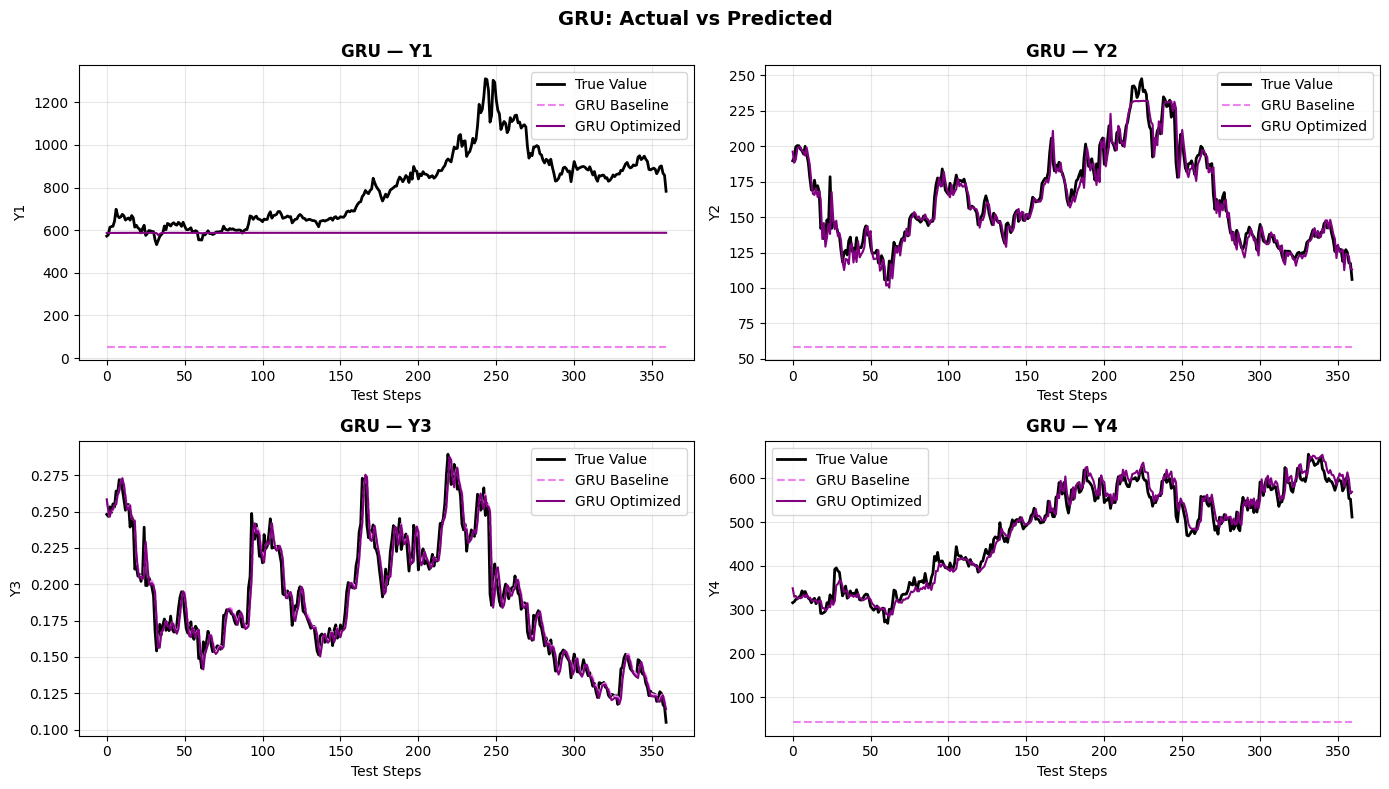

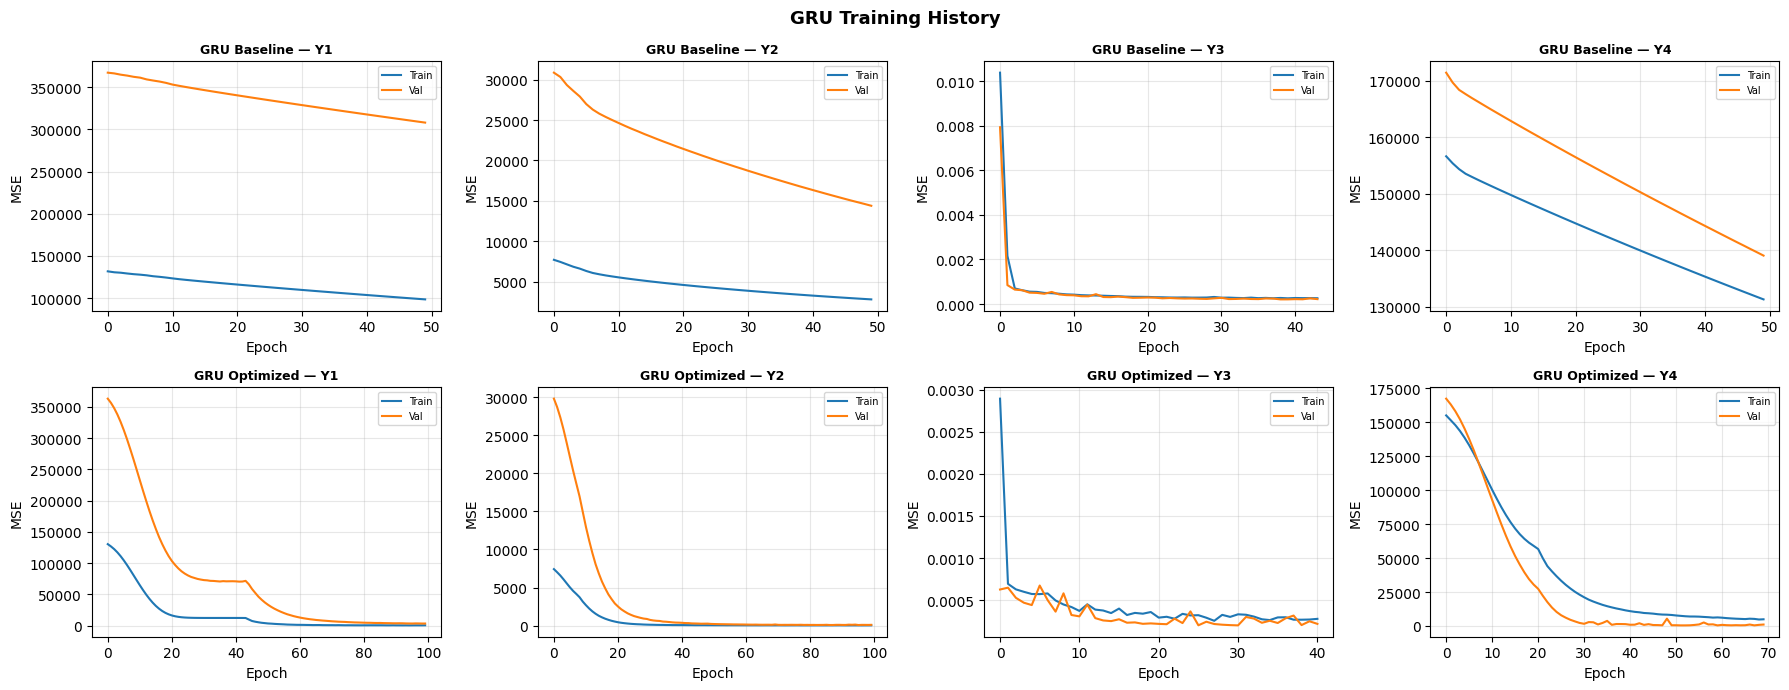

In [ ]:
# Actual vs Predicted — GRU
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],             color='black',   linewidth=2,    label='True Value')
    ax.plot(p['GRU (Baseline)'],   color='violet',  linestyle='--', label='GRU Baseline')
    ax.plot(p['GRU (Optimized)'],  color='purple',  linestyle='-',  label='GRU Optimized')
    ax.set_title(f'GRU — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('GRU: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Training loss
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('GRU_base','Baseline'), ('GRU_opt','Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'GRU {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('GRU Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## X. Model 6 — 1D CNN

A 1D Convolutional Neural Network slides learned filters across the 30-lag window,
capturing **local temporal patterns** at multiple scales.

- **Baseline**: single Conv1D block (64 filters, kernel=3) → MaxPool → Flatten → Dense 32
- **Optimized**: two stacked Conv1D blocks (64 → 128 filters, kernel=3) with increasing
  receptive field → MaxPool → Dense 64 → Dense 32, lower LR (`5e-4`), patience=15

### 10.1 1D CNN — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        Conv1D(64, kernel_size=3, activation='relu',
               padding='same', input_shape=(WINDOW_SIZE, 1)),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=50, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'CNN (Baseline)')
    DL_HIST[target_col]['CNN_base'] = h

print('CNN Baseline done.')

### 10.2 1D CNN — Optimized (Deeper Conv Blocks + Lower LR)

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        # First conv block
        Conv1D(64,  kernel_size=3, activation='relu',
               padding='same', input_shape=(WINDOW_SIZE, 1)),
        MaxPooling1D(pool_size=2),
        # Second conv block — wider receptive field
        Conv1D(128, kernel_size=3, activation='relu', padding='same'),
        MaxPooling1D(pool_size=2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=100, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'CNN (Optimized)')
    DL_HIST[target_col]['CNN_opt'] = h

print('CNN Optimized done.')

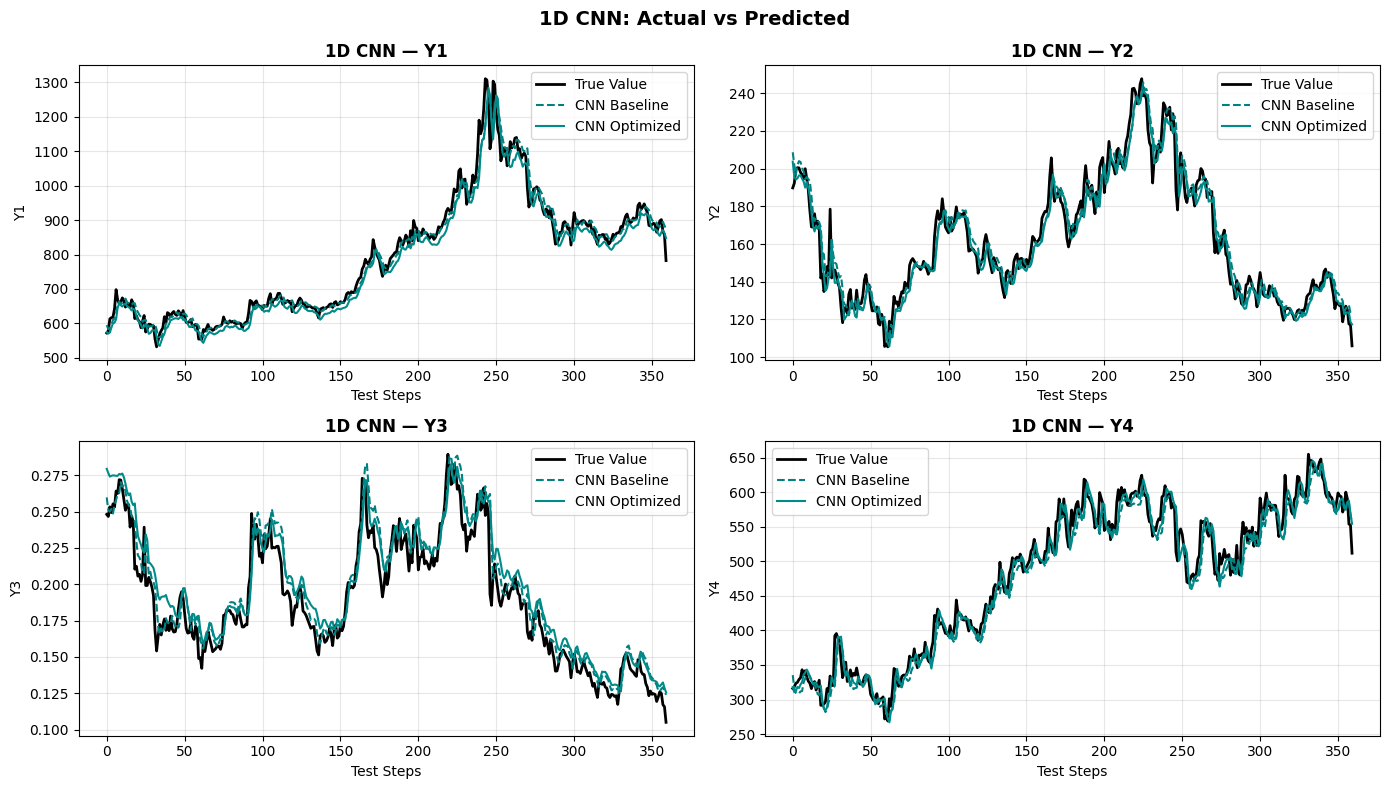

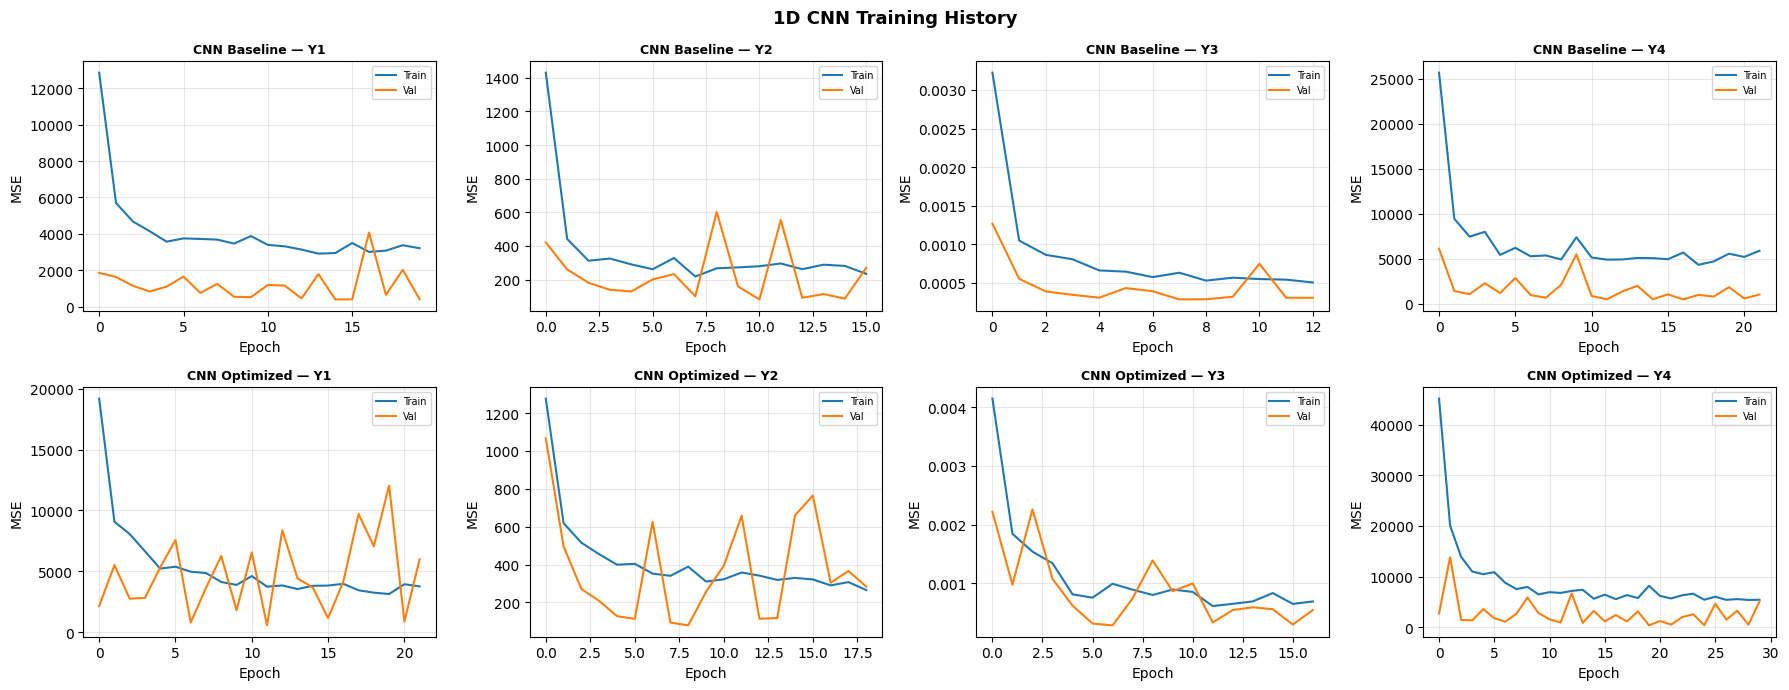

In [ ]:
# Actual vs Predicted — 1D CNN
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],            color='black',     linewidth=2,    label='True Value')
    ax.plot(p['CNN (Baseline)'],  color='teal',      linestyle='--', label='CNN Baseline')
    ax.plot(p['CNN (Optimized)'], color='darkcyan',  linestyle='-',  label='CNN Optimized')
    ax.set_title(f'1D CNN — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('1D CNN: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Training loss — 1D CNN
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('CNN_base','Baseline'), ('CNN_opt','Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'CNN {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('1D CNN Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## XI. Model 7 — Bidirectional LSTM (BiLSTM)

A Bidirectional LSTM processes the sequence in **both forward and backward directions**,
allowing the network to capture patterns from past *and* future context within the window.

- **Baseline**: single `Bidirectional(LSTM(32))` layer → Dense 1
- **Optimized**: stacked `Bidirectional(LSTM(64, return_sequences=True))` →
  `Bidirectional(LSTM(32))` → Dropout → Dense 16 → Dense 1, patience=15

### 11.1 BiLSTM — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        Bidirectional(LSTM(32, activation='tanh'),
                      input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=50, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'BiLSTM (Baseline)')
    DL_HIST[target_col]['BiLSTM_base'] = h

print('BiLSTM Baseline done.')

### 11.2 BiLSTM — Optimized (Stacked + Dropout + Early Stopping)

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        Bidirectional(
            LSTM(64, activation='tanh', return_sequences=True),
            input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        Bidirectional(LSTM(32, activation='tanh')),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=100, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'BiLSTM (Optimized)')
    DL_HIST[target_col]['BiLSTM_opt'] = h

print('BiLSTM Optimized done.')

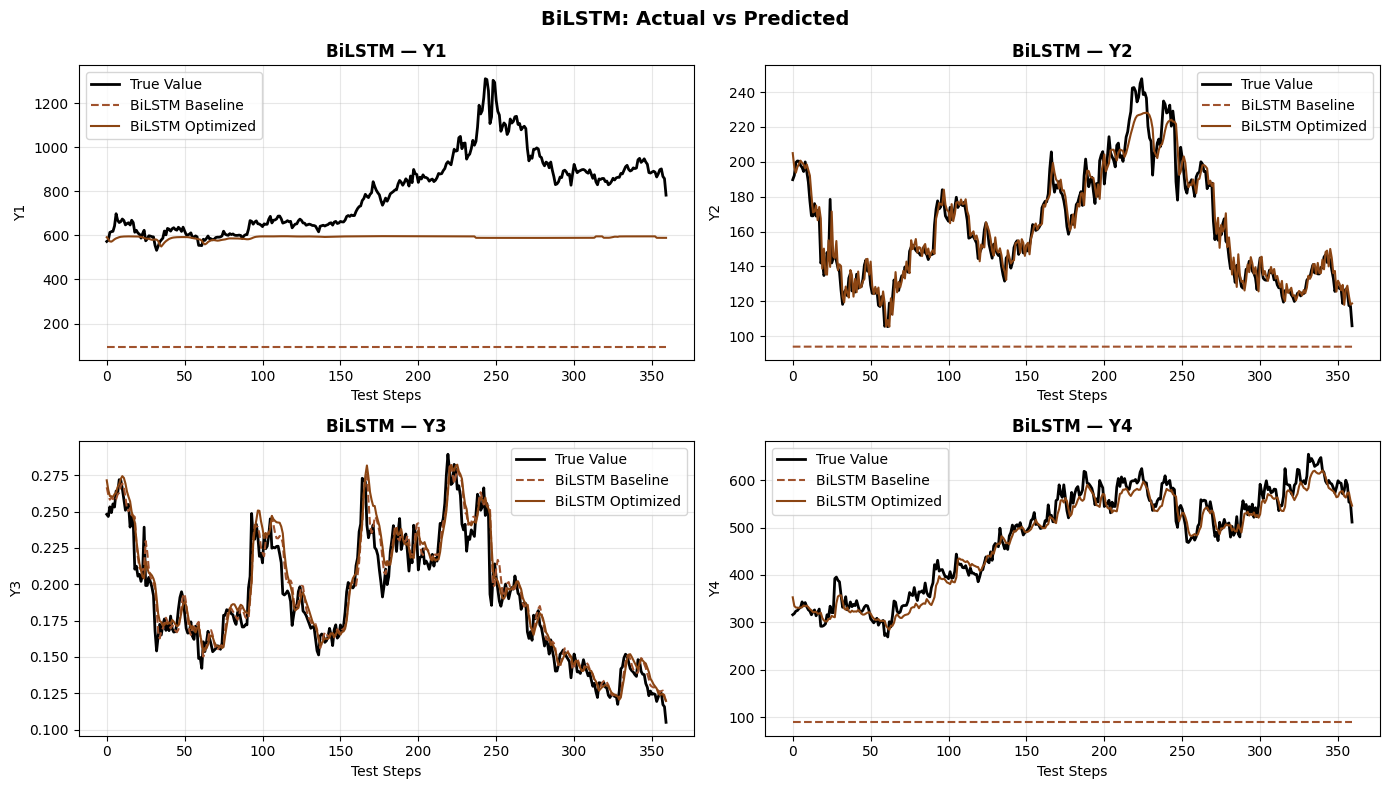

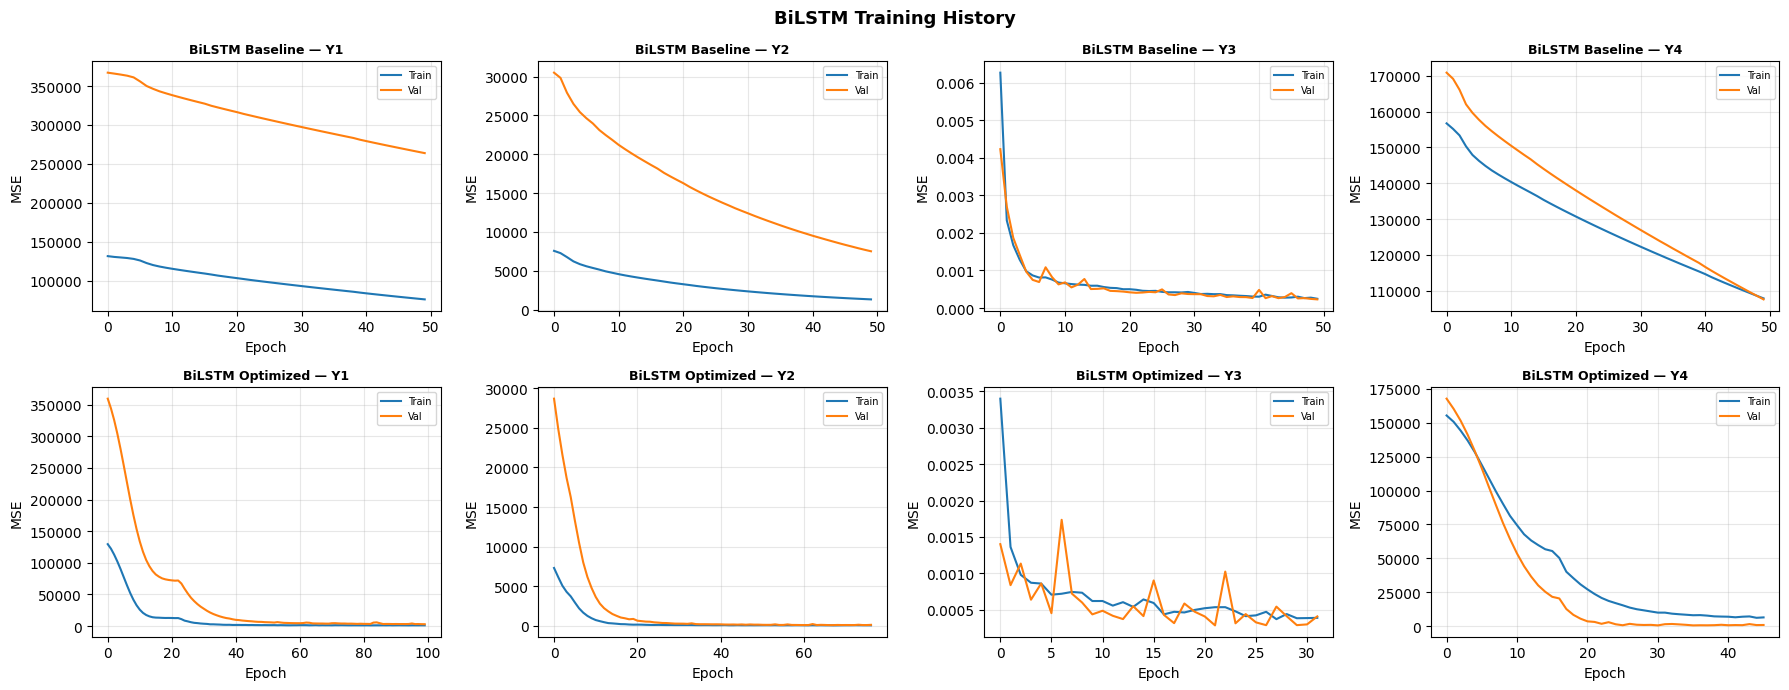

In [ ]:
# Actual vs Predicted — BiLSTM
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],               color='black',    linewidth=2,    label='True Value')
    ax.plot(p['BiLSTM (Baseline)'],  color='sienna',   linestyle='--', label='BiLSTM Baseline')
    ax.plot(p['BiLSTM (Optimized)'], color='saddlebrown', linestyle='-', label='BiLSTM Optimized')
    ax.set_title(f'BiLSTM — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('BiLSTM: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Training loss — BiLSTM
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('BiLSTM_base','Baseline'),
                                        ('BiLSTM_opt', 'Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'BiLSTM {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('BiLSTM Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## XII. Model 8 — Bidirectional GRU (Bi-GRU)

Bi-GRU processes the lag sequence in both directions simultaneously, combining
the efficiency of GRU (fewer parameters than LSTM) with bidirectional context.

- **Baseline**: single `Bidirectional(GRU(32))` → Dense 1, patience=5, 50 epochs
- **Optimized**: stacked `Bidirectional(GRU(64, return_sequences=True))` →
  `Bidirectional(GRU(32))` + Dropout(0.2) → Dense 16 → Dense 1, patience=10, 100 epochs

### 12.1 Bi-GRU — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        Bidirectional(GRU(32, activation='tanh'),
                      input_shape=(WINDOW_SIZE, 1)),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=5,
                        restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=50, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'Bi-GRU (Baseline)')
    DL_HIST[target_col]['BiGRU_base'] = h

print('Bi-GRU Baseline done.')

### 12.2 Bi-GRU — Optimized (Stacked + Dropout + Early Stopping)

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    K.clear_session()
    m = Sequential([
        Bidirectional(
            GRU(64, activation='tanh', return_sequences=True),
            input_shape=(WINDOW_SIZE, 1)),
        Dropout(0.2),
        Bidirectional(GRU(32, activation='tanh')),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    m.compile(optimizer='adam', loss='mse')
    cb = [EarlyStopping(monitor='val_loss', patience=10,
                        restore_best_weights=True)]
    h  = m.fit(d['X_tr_dl'], d['y_tr'], validation_split=0.2,
               epochs=100, batch_size=32, callbacks=cb, verbose=0)
    print(f'  [{target_col}] stopped at epoch {len(h.history["loss"])}')
    store(target_col, d['y_te'],
          m.predict(d['X_te_dl'], verbose=0).flatten(), 'Bi-GRU (Optimized)')
    DL_HIST[target_col]['BiGRU_opt'] = h

print('Bi-GRU Optimized done.')

  [Y1] stopped at epoch 87
  [Y1] Bi-GRU (Optimized)                             RMSE=276.8238  MAE=217.3708  MAPE=24.19%


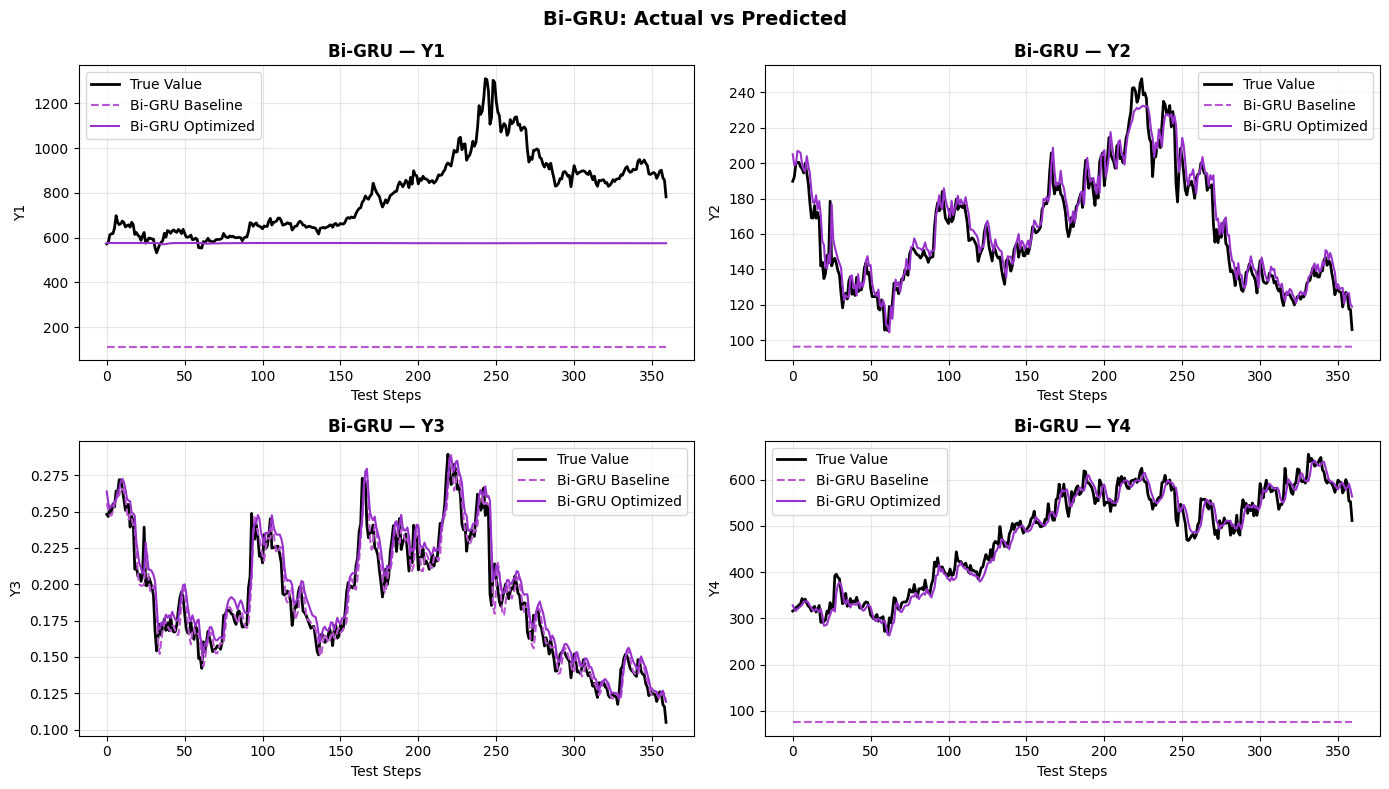

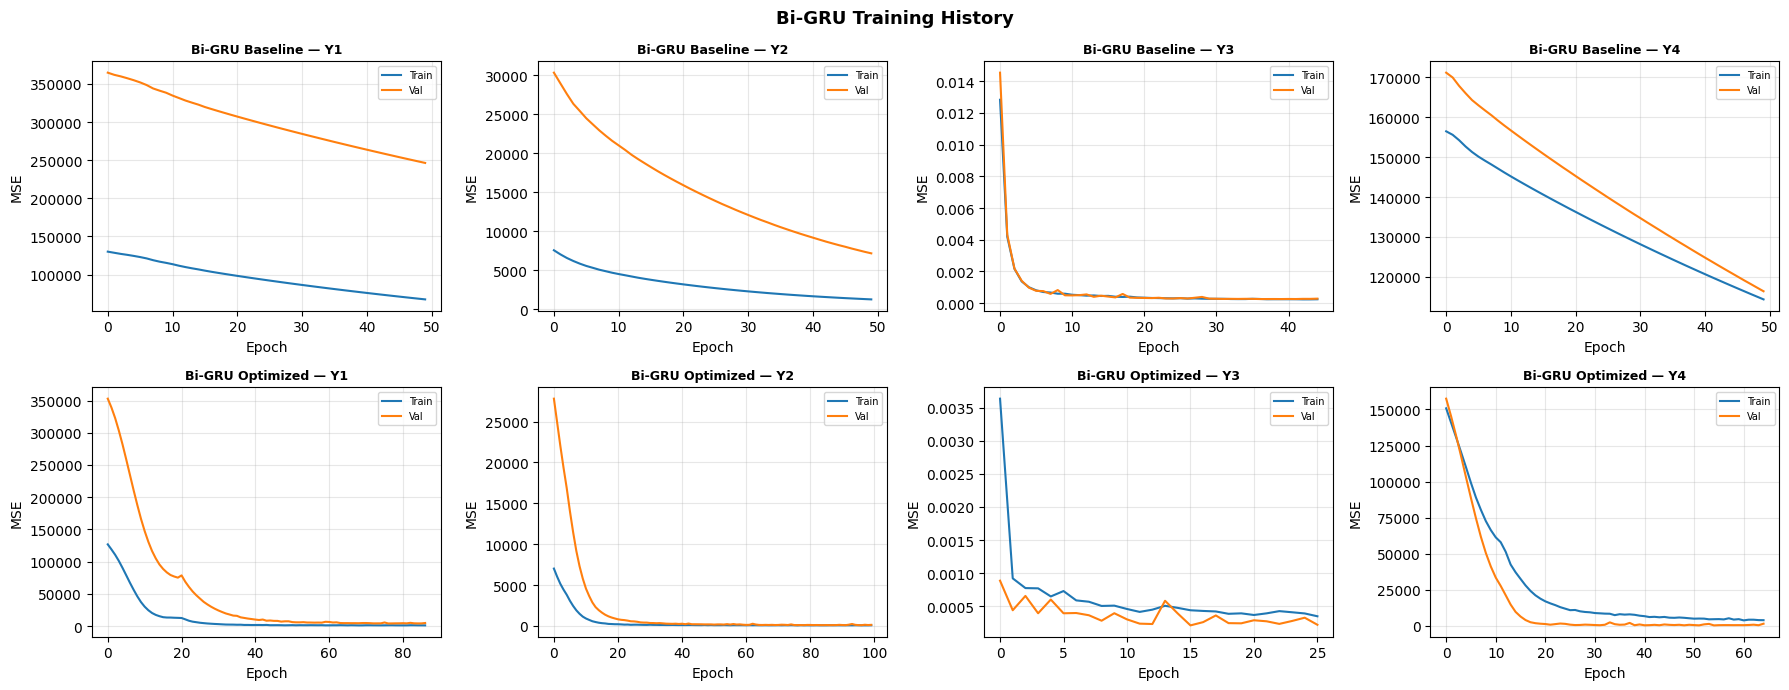

In [ ]:
# Actual vs Predicted — Bi-GRU
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],               color='black',      linewidth=2,    label='True Value')
    ax.plot(p['Bi-GRU (Baseline)'],  color='mediumorchid', linestyle='--', label='Bi-GRU Baseline')
    ax.plot(p['Bi-GRU (Optimized)'], color='darkorchid', linestyle='-',  label='Bi-GRU Optimized')
    ax.set_title(f'Bi-GRU — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Bi-GRU: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Training loss — Bi-GRU
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('BiGRU_base', 'Baseline'),
                                        ('BiGRU_opt',  'Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'Bi-GRU {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('Bi-GRU Training History', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## XIII. Model 9 — Support Vector Regression (SVR)

SVR finds a regression
function that keeps predictions within an ε-tube of the true values, controlled
by regularisation parameter C. The RBF kernel maps the lag features into a
high-dimensional space to capture nonlinear dependencies.

- **Baseline**: RBF kernel, sklearn defaults (`C=1`, `ε=0.1`, `γ='scale'`)
- **Optimized**: Grid Search over C ∈ {0.1,1,10,100}, ε ∈ {0.01,0.1,0.5},
  γ ∈ {'scale','auto'} with 5-fold `TimeSeriesSplit` CV

### 13.1 SVR — Baseline

In [ ]:
for target_col in SELECTED:
    d = DATA[target_col]
    # Pipeline: scale then fit SVR (prevents leakage)
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svr',    SVR(kernel='rbf', C=1.0,
                                    epsilon=0.1, gamma='scale'))])
    pipe.fit(d['X_tr'], d['y_tr'])
    store(target_col, d['y_te'],
          pipe.predict(d['X_te']), 'SVR (Baseline)')

print('SVR Baseline done.')

### 13.2 SVR — Optimized (Grid Search + TimeSeriesSplit CV)

In [ ]:
svr_param_grid = {
    'svr__C'      : [0.1, 1, 10, 100],
    'svr__epsilon': [0.01, 0.1, 0.5],
    'svr__gamma'  : ['scale', 'auto']
}

for target_col in SELECTED:
    d = DATA[target_col]
    pipe = Pipeline([('scaler', StandardScaler()),
                     ('svr',    SVR(kernel='rbf'))])
    gs = GridSearchCV(pipe, svr_param_grid, cv=tscv,
                      scoring='neg_root_mean_squared_error',
                      n_jobs=-1, verbose=0)
    gs.fit(d['X_tr'], d['y_tr'])
    print(f'  [{target_col}] Best: {gs.best_params_}  '
          f'CV-RMSE={-gs.best_score_:.4f}')
    store(target_col, d['y_te'],
          gs.best_estimator_.predict(d['X_te']), 'SVR (Grid Search)')

print('SVR Grid Search done.')

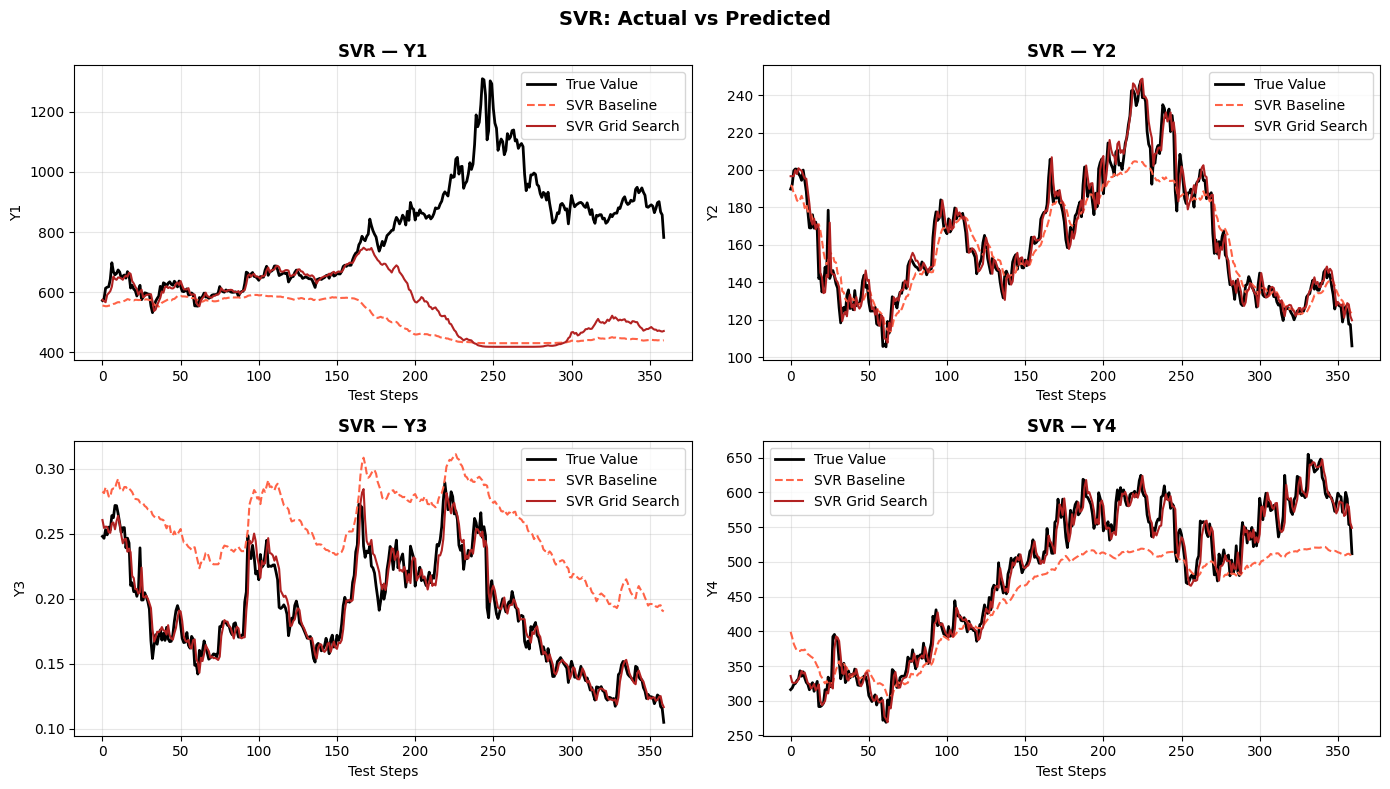

In [ ]:
# Actual vs Predicted — SVR
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],            color='black',    linewidth=2,    label='True Value')
    ax.plot(p['SVR (Baseline)'],  color='tomato',   linestyle='--', label='SVR Baseline')
    ax.plot(p['SVR (Grid Search)'],color='firebrick',linestyle='-',  label='SVR Grid Search')
    ax.set_title(f'SVR — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('SVR: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## XIV. Model 10 — Extreme Learning Machine (ELM)

ELM is a single-hidden-layer
feedforward network where **input weights and biases are randomly initialised
and fixed**.

- **Baseline**: 500 hidden neurons, ReLU activation, no regularisation
- **Optimized**: 1000 hidden neurons, ReLU activation, L2 Tikhonov regularisation
  (ridge-style: $\hat{\beta} = (H^TH + \lambda I)^{-1}H^Ty$) with λ tuned by
  cross-validation over {0.001, 0.01, 0.1, 1.0}

### 14.1 ELM — Implementation

In [ ]:
class ELM:
    """
    Extreme Learning Machine for regression.
    Input weights are randomly fixed; output weights solved analytically.
    """
    def __init__(self, n_hidden=500, activation='relu', lam=0.0, random_state=42):
        self.n_hidden    = n_hidden
        self.activation  = activation
        self.lam         = lam          # L2 regularisation (0 = no reg)
        self.random_state = random_state
        self.W = None   # input weights
        self.b = None   # biases
        self.beta = None  # output weights

    def _hidden(self, X):
        H = X @ self.W + self.b
        if self.activation == 'relu':
            return np.maximum(0, H)
        return np.tanh(H)

    def fit(self, X, y):
        rng = np.random.default_rng(self.random_state)
        n_feat = X.shape[1]
        self.W = rng.normal(0, 1, (n_feat, self.n_hidden))
        self.b = rng.normal(0, 1, (1, self.n_hidden))
        H = self._hidden(X)
        if self.lam == 0.0:
            self.beta = np.linalg.pinv(H) @ y
        else:
            I = np.eye(self.n_hidden)
            self.beta = np.linalg.solve(
                H.T @ H + self.lam * I, H.T @ y)
        return self

    def predict(self, X):
        return self._hidden(X) @ self.beta


print('ELM class defined.')

### 14.2 ELM — Baseline (500 hidden neurons, no regularisation)

In [ ]:
from sklearn.preprocessing import StandardScaler as _SS

for target_col in SELECTED:
    d = DATA[target_col]
    sc = _SS()
    X_tr_sc = sc.fit_transform(d['X_tr'])
    X_te_sc = sc.transform(d['X_te'])
    elm = ELM(n_hidden=500, activation='relu', lam=0.0)
    elm.fit(X_tr_sc, d['y_tr'])
    store(target_col, d['y_te'],
          elm.predict(X_te_sc), 'ELM (Baseline)')

print('ELM Baseline done.')

### 14.3 ELM — Optimized (1000 neurons + L2 Regularisation, λ by CV)

In [ ]:
best_lam_per_col = {}

for target_col in SELECTED:
    d = DATA[target_col]
    sc = _SS()
    X_tr_sc = sc.fit_transform(d['X_tr'])
    X_te_sc = sc.transform(d['X_te'])

    # Select best λ via TimeSeriesSplit CV on training data
    best_lam, best_cv_rmse = None, np.inf
    for lam in [0.001, 0.01, 0.1, 1.0]:
        fold_rmses = []
        for tr_idx, va_idx in tscv.split(X_tr_sc):
            elm_cv = ELM(n_hidden=1000, lam=lam)
            elm_cv.fit(X_tr_sc[tr_idx], d['y_tr'][tr_idx])
            preds_va = elm_cv.predict(X_tr_sc[va_idx])
            fold_rmses.append(
                np.sqrt(mean_squared_error(d['y_tr'][va_idx], preds_va)))
        cv_rmse = np.mean(fold_rmses)
        if cv_rmse < best_cv_rmse:
            best_cv_rmse, best_lam = cv_rmse, lam

    best_lam_per_col[target_col] = best_lam
    print(f'  [{target_col}] best λ={best_lam}  CV-RMSE={best_cv_rmse:.4f}')

    elm_opt = ELM(n_hidden=1000, lam=best_lam)
    elm_opt.fit(X_tr_sc, d['y_tr'])
    store(target_col, d['y_te'],
          elm_opt.predict(X_te_sc), 'ELM (Optimized)')

print('ELM Optimized done.')

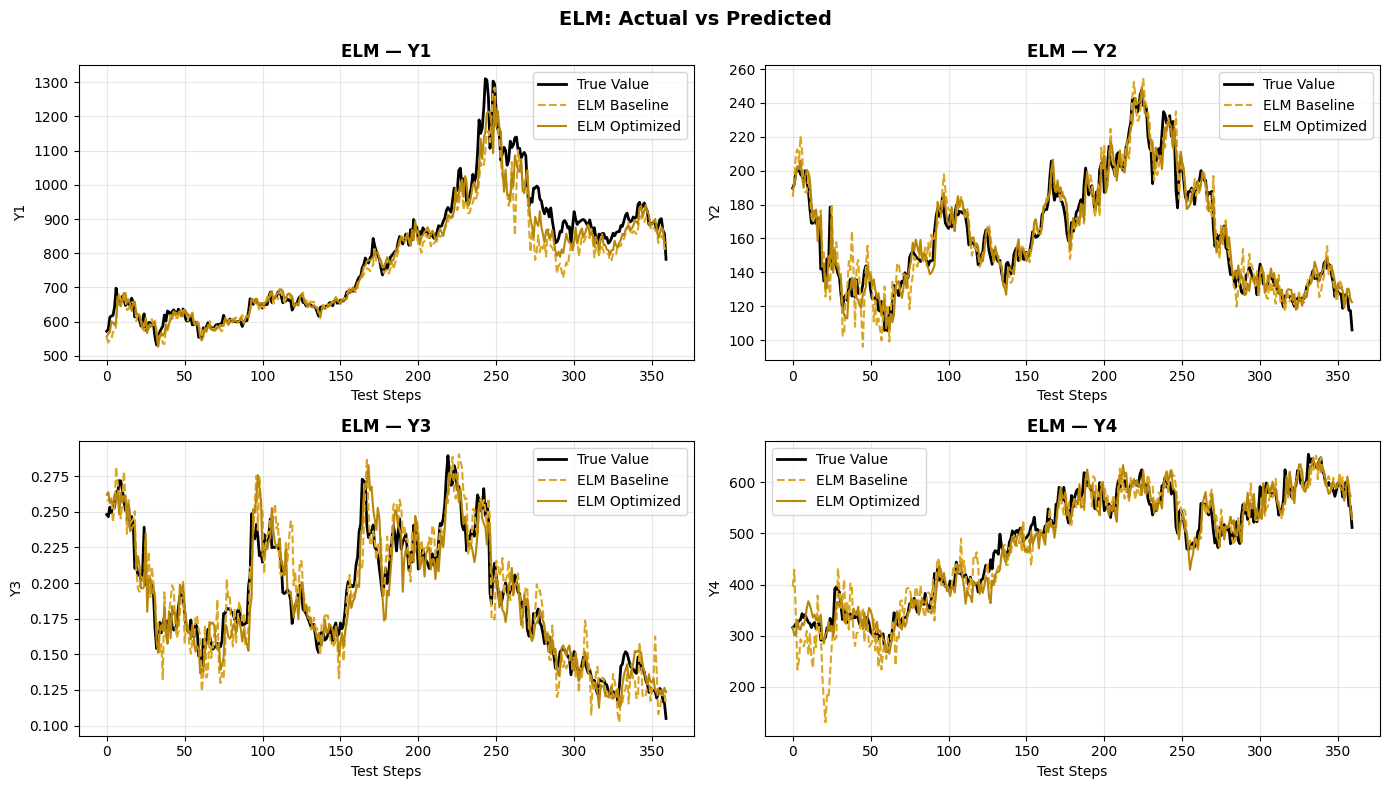

In [ ]:
# Actual vs Predicted — ELM
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],            color='black',      linewidth=2,    label='True Value')
    ax.plot(p['ELM (Baseline)'],  color='goldenrod',  linestyle='--', label='ELM Baseline')
    ax.plot(p['ELM (Optimized)'], color='darkgoldenrod', linestyle='-', label='ELM Optimized')
    ax.set_title(f'ELM — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('ELM: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## XV. Model 11 — Autoencoder + Dense Regressor

An autoencoder compresses the 30-lag
window into a lower-dimensional latent code (unsupervised). The encoder output is
then fed to a supervised Dense regression head.

- **Baseline**: encoding_dim=15, single Dense regressor (32 → 1)
- **Optimized**: encoding_dim=20, deeper decoder, regressor (64 → 32 → 1),
  `ReduceLROnPlateau` on both training stages

### 15.1 Autoencoder + Dense — Baseline

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau


def run_ae_regressor(target_col, enc_dim, reg_units,
                     epochs_ae=50, epochs_reg=50,
                     patience=5, lr_reduce=False, label_suffix='Baseline'):
    """Train autoencoder on X_tr_dl (flattened), then train Dense regressor."""
    d    = DATA[target_col]
    # Flatten 3-D → 2-D for the autoencoder
    X_tr_flat = d['X_tr_dl'].reshape(len(d['X_tr_dl']), -1)
    X_te_flat = d['X_te_dl'].reshape(len(d['X_te_dl']), -1)
    in_dim = X_tr_flat.shape[1]

    K.clear_session()

    # --- Autoencoder ---
    inp      = Input(shape=(in_dim,))
    encoded  = Dense(enc_dim, activation='relu')(inp)
    decoded  = Dense(in_dim,  activation='linear')(encoded)
    ae       = Model(inp, decoded)
    encoder  = Model(inp, encoded)
    ae.compile(optimizer='adam', loss='mse')

    ae_cbs = [EarlyStopping(monitor='val_loss', patience=patience,
                            restore_best_weights=True)]
    if lr_reduce:
        ae_cbs.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                        patience=3, min_lr=1e-6, verbose=0))
    ae.fit(X_tr_flat, X_tr_flat, validation_split=0.2,
           epochs=epochs_ae, batch_size=32, callbacks=ae_cbs, verbose=0)

    X_tr_enc = encoder.predict(X_tr_flat, verbose=0)
    X_te_enc = encoder.predict(X_te_flat, verbose=0)

    # --- Regressor ---
    reg_inp = Input(shape=(enc_dim,))
    x = reg_inp
    for units in reg_units:
        x = Dense(units, activation='relu')(x)
        x = Dropout(0.2)(x)
    reg_out = Dense(1)(x)
    reg = Model(reg_inp, reg_out)
    reg.compile(optimizer='adam', loss='mse')

    reg_cbs = [EarlyStopping(monitor='val_loss', patience=patience,
                             restore_best_weights=True)]
    if lr_reduce:
        reg_cbs.append(ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                         patience=3, min_lr=1e-6, verbose=0))
    h = reg.fit(X_tr_enc, d['y_tr'], validation_split=0.2,
                epochs=epochs_reg, batch_size=32, callbacks=reg_cbs, verbose=0)

    label = f'AE+Dense ({label_suffix})'
    store(target_col, d['y_te'],
          reg.predict(X_te_enc, verbose=0).flatten(), label)
    DL_HIST[target_col][f'AE_{label_suffix}'] = h
    print(f'  [{target_col}] AE stopped at reg epoch {len(h.history["loss"])}')


print('Training AE + Dense Baseline...')
for target_col in SELECTED:
    run_ae_regressor(target_col, enc_dim=15, reg_units=(32,),
                     epochs_ae=50, epochs_reg=50, patience=5,
                     lr_reduce=False, label_suffix='Baseline')
print('AE + Dense Baseline done.')

### 15.2 Autoencoder + Dense — Optimized (Deeper + ReduceLROnPlateau)

In [ ]:
print('Training AE + Dense Optimized...')
for target_col in SELECTED:
    run_ae_regressor(target_col, enc_dim=20, reg_units=(64, 32),
                     epochs_ae=100, epochs_reg=100, patience=10,
                     lr_reduce=True, label_suffix='Optimized')
print('AE + Dense Optimized done.')

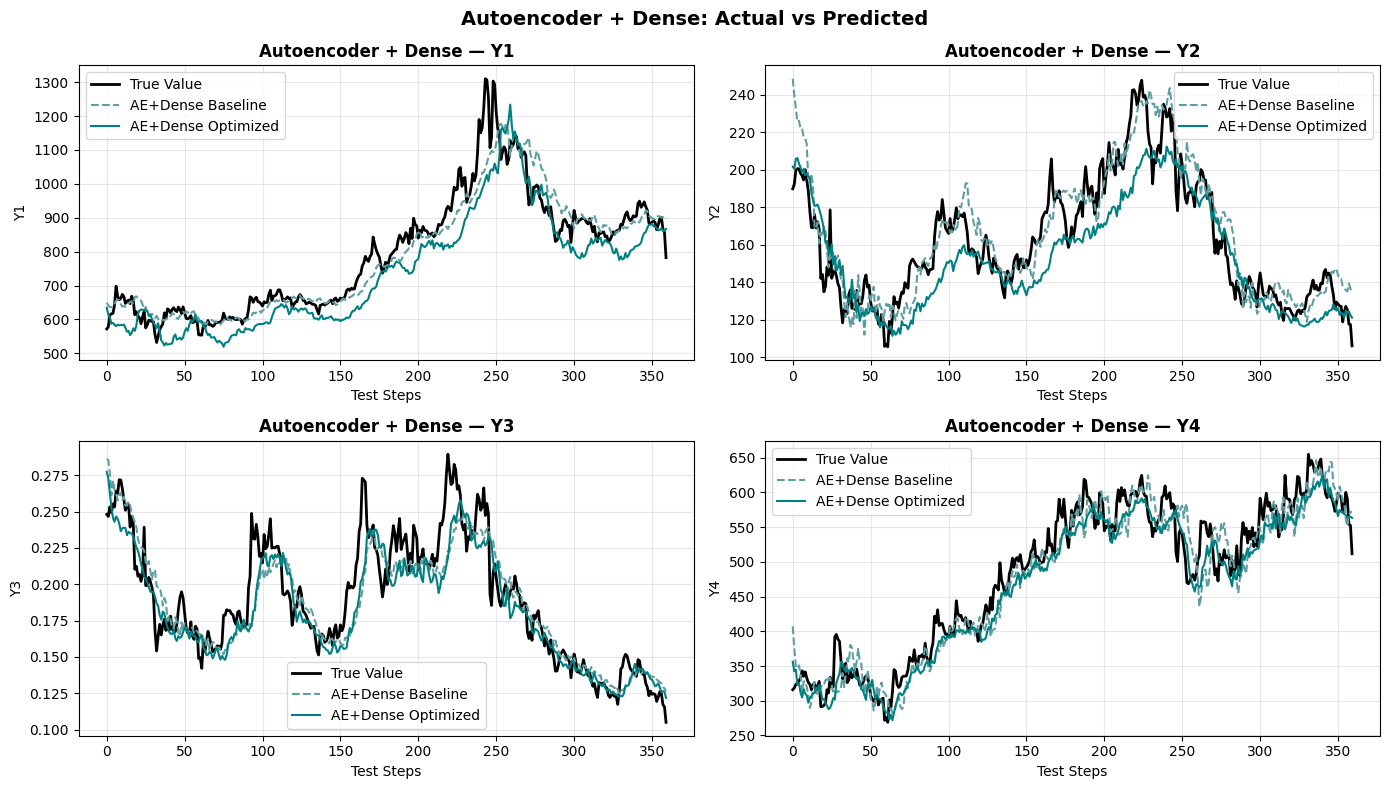

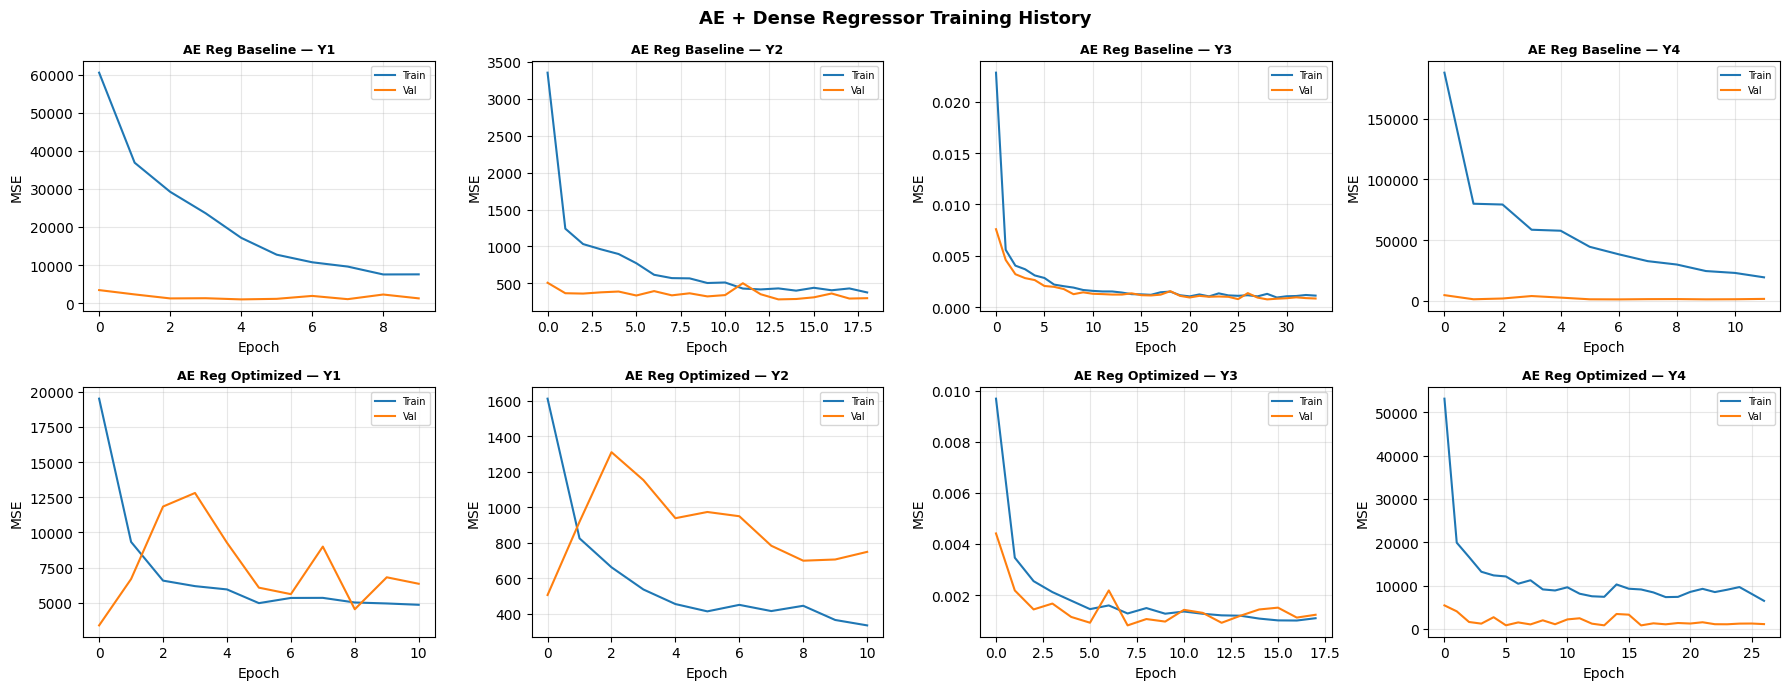

In [ ]:
# Actual vs Predicted — AE + Dense
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, col in zip(axes.ravel(), SELECTED):
    d = DATA[col]; p = ALL_PREDS[col]
    ax.plot(d['y_te'],                    color='black',    linewidth=2,    label='True Value')
    ax.plot(p['AE+Dense (Baseline)'],     color='cadetblue',linestyle='--', label='AE+Dense Baseline')
    ax.plot(p['AE+Dense (Optimized)'],    color='teal',     linestyle='-',  label='AE+Dense Optimized')
    ax.set_title(f'Autoencoder + Dense — {col}', fontweight='bold')
    ax.set_xlabel('Test Steps'); ax.set_ylabel(col)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Autoencoder + Dense: Actual vs Predicted',
             fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

# Regressor training loss — AE + Dense
fig, axes = plt.subplots(2, 4, figsize=(18, 7))
for i, col in enumerate(SELECTED):
    for j, (hkey, title) in enumerate([('AE_Baseline', 'Baseline'),
                                        ('AE_Optimized','Optimized')]):
        ax = axes[j, i]
        h  = DL_HIST[col][hkey]
        ax.plot(h.history['loss'],     label='Train')
        ax.plot(h.history['val_loss'], label='Val')
        ax.set_title(f'AE Reg {title} — {col}', fontweight='bold', fontsize=9)
        ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
        ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
plt.suptitle('AE + Dense Regressor Training History',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## XVI. Consolidated Performance Metrics Table

In [ ]:
# Build flat DataFrame from all collected results
all_records = [r for col in SELECTED for r in ALL_RESULTS[col]]
full_df = pd.DataFrame(all_records)[['Series','Model','RMSE','MAE','MAD','MAPE']]

# Per-series ranked tables
print('=' * 65)
print('  PERFORMANCE METRICS BY SERIES  (ranked by RMSE)')
print('=' * 65)
for col in SELECTED:
    sub = (full_df[full_df['Series'] == col]
           .drop(columns='Series')
           .sort_values('RMSE')
           .reset_index(drop=True))
    sub.index += 1
    print(f'\n── {col} ' + '─'*50)
    print(sub.to_string())

# RMSE pivot
pivot = full_df.pivot_table(index='Model', columns='Series', values='RMSE')
pivot.columns.name = None
pivot['Mean RMSE'] = pivot[SELECTED].mean(axis=1)
pivot = pivot.round(4).sort_values('Mean RMSE')
print('\n── RMSE Pivot (rows=models, cols=series) ' + '─'*20)
print(pivot.to_string())

  PERFORMANCE METRICS BY SERIES  (ranked by RMSE)

── Y1 ──────────────────────────────────────────────────
                       Model      RMSE       MAE       MAD   MAPE
1           ARIMA (Baseline)   25.3567   15.7688   15.7688   1.91
2             CNN (Baseline)   29.3806   18.7370   18.7370   2.24
3            CNN (Optimized)   34.2796   25.6858   25.6858   3.13
4            ELM (Optimized)   40.7380   27.0185   27.0185   3.10
5        AE+Dense (Baseline)   53.6851   35.7275   35.7275   4.21
6             ELM (Baseline)   55.6027   36.9016   36.9016   4.24
7       AE+Dense (Optimized)   79.3886   63.5266   63.5266   7.87
8           RF (Grid Search)  176.6608  118.4123  118.4123  12.44
9              RF (Baseline)  179.7411  121.5827  121.5827  12.82
10        XGBoost (Baseline)  182.4223  124.3672  124.3672  13.17
11   XGBoost (Random Search)  184.9610  126.9558  126.9558  13.48
12  XGBoost (Bayes Fallback)  185.8241  127.1329  127.1329  13.47
13        BiLSTM (Optimized)  263.

In [ ]:
# Styled HTML tables
def highlight_min(s):
    return ['background-color:#c6efce;font-weight:bold' if v == s.min() else '' for v in s]

for metric in ['RMSE', 'MAE', 'MAD', 'MAPE']:
    piv = full_df.pivot_table(index='Model', columns='Series', values=metric)
    piv.columns.name = None
    piv = piv[SELECTED].round(4)
    piv['Mean'] = piv.mean(axis=1).round(4)
    piv = piv.sort_values('Mean')
    display(
        piv.style
        .apply(highlight_min, axis=0, subset=SELECTED)
        .set_caption(f'{metric} — all models × all series  (green = best per series)')
        .format('{:.4f}')
    )

,Y1,Y2,Y3,Y4,Mean
Model,,,,,
ARIMA (Baseline),25.3567,7.3355,0.0104,17.5980,12.5751
CNN (Baseline),29.3806,8.1881,0.0135,21.8169,14.8498
CNN (Optimized),34.2796,7.8414,0.0152,19.7481,15.4711
ELM (Optimized),40.7380,8.1687,0.0142,24.4311,18.3380
AE+Dense (Baseline),53.6851,14.2327,0.0195,33.4712,25.3521
ELM (Baseline),55.6027,10.8632,0.0179,36.8315,25.8288
AE+Dense (Optimized),79.3886,17.8322,0.0191,28.4585,31.4246
RF (Grid Search),176.6608,7.7961,0.0114,18.8379,50.8266
RF (Baseline),179.7411,7.8518,0.0114,19.7594,51.8409


,Y1,Y2,Y3,Y4,Mean
Model,,,,,
ARIMA (Baseline),15.7688,5.2891,0.0074,13.0730,8.5346
CNN (Baseline),18.7370,6.1476,0.0105,16.3401,10.3088
CNN (Optimized),25.6858,5.8315,0.0123,14.7259,11.5639
ELM (Optimized),27.0185,6.2563,0.0105,19.0346,13.0800
ELM (Baseline),36.9016,7.7785,0.0140,27.3571,18.0128
AE+Dense (Baseline),35.7275,11.0283,0.0140,25.9717,18.1854
AE+Dense (Optimized),63.5266,14.3124,0.0139,22.6341,25.1218
RF (Grid Search),118.4123,5.6876,0.0080,14.1037,34.5529
RF (Baseline),121.5827,5.7201,0.0080,15.0481,35.5897


,Y1,Y2,Y3,Y4,Mean
Model,,,,,
ARIMA (Baseline),15.7688,5.2891,0.0074,13.0730,8.5346
CNN (Baseline),18.7370,6.1476,0.0105,16.3401,10.3088
CNN (Optimized),25.6858,5.8315,0.0123,14.7259,11.5639
ELM (Optimized),27.0185,6.2563,0.0105,19.0346,13.0800
ELM (Baseline),36.9016,7.7785,0.0140,27.3571,18.0128
AE+Dense (Baseline),35.7275,11.0283,0.0140,25.9717,18.1854
AE+Dense (Optimized),63.5266,14.3124,0.0139,22.6341,25.1218
RF (Grid Search),118.4123,5.6876,0.0080,14.1037,34.5529
RF (Baseline),121.5827,5.7201,0.0080,15.0481,35.5897


,Y1,Y2,Y3,Y4,Mean
Model,,,,,
ARIMA (Baseline),1.9100,3.2300,3.7500,2.7900,2.9200
CNN (Baseline),2.2400,3.8300,5.6200,3.4400,3.7825
CNN (Optimized),3.1300,3.5900,6.7500,3.1000,4.1425
ELM (Optimized),3.1000,3.9900,5.4800,4.1100,4.1700
RF (Grid Search),12.4400,3.5800,4.1200,2.9700,5.7775
ELM (Baseline),4.2400,5.0000,7.5300,6.4500,5.8050
RF (Baseline),12.8200,3.6000,4.1300,3.1700,5.9300
AE+Dense (Baseline),4.2100,6.9800,7.0900,5.5500,5.9575
XGBoost (Baseline),13.1700,3.6600,4.0600,3.2500,6.0350


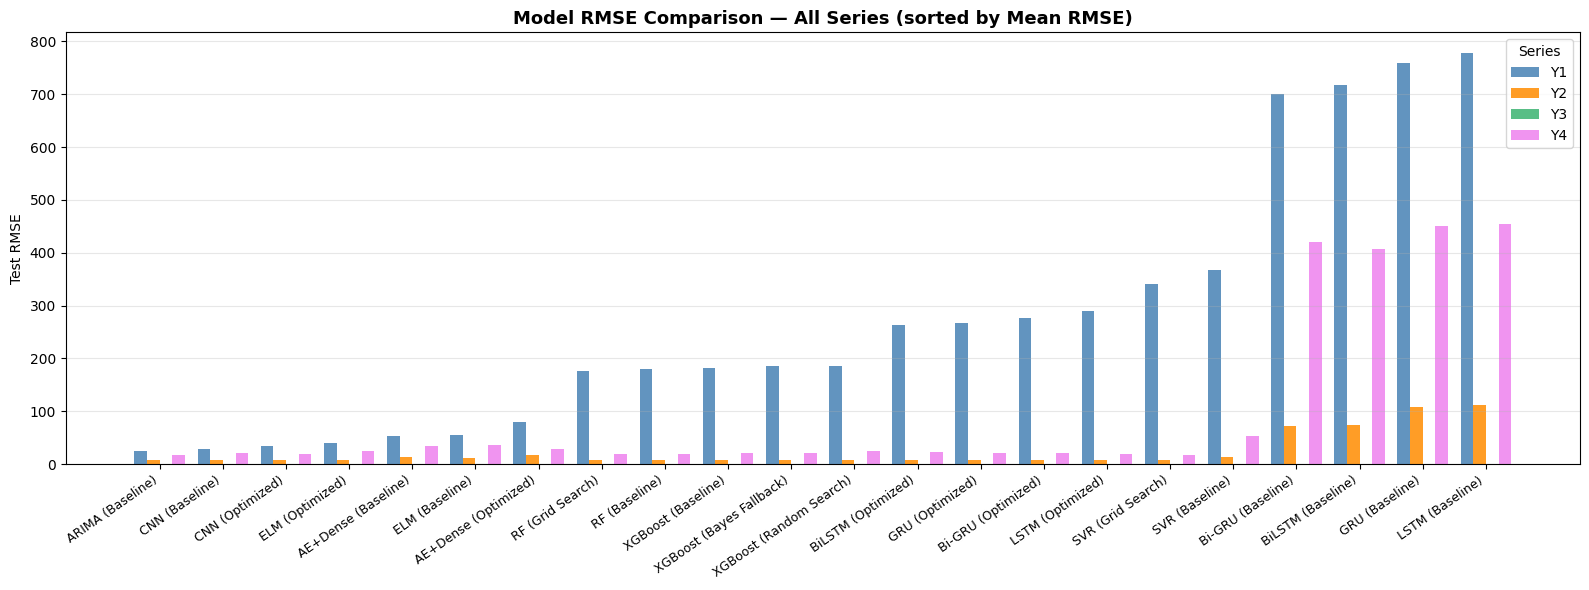

In [ ]:
# Grouped bar chart: RMSE by model, one bar group per series
models_ordered = (
    full_df.groupby('Model')['RMSE'].mean().sort_values().index.tolist()
)
x      = np.arange(len(models_ordered))
width  = 0.2
colors = ['steelblue', 'darkorange', 'mediumseagreen', 'violet']

fig, ax = plt.subplots(figsize=(16, 6))
for i, (col, color) in enumerate(zip(SELECTED, colors)):
    sub  = full_df[full_df['Series'] == col].set_index('Model')
    vals = [sub.loc[m, 'RMSE'] if m in sub.index else 0 for m in models_ordered]
    ax.bar(x + i * width, vals, width, label=col, color=color, alpha=0.85)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(models_ordered, rotation=35, ha='right', fontsize=9)
ax.set_ylabel('Test RMSE')
ax.set_title('Model RMSE Comparison — All Series (sorted by Mean RMSE)',
             fontsize=13, fontweight='bold')
ax.legend(title='Series'); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

## XVII. Export Predictions & Metrics to Excel

In [ ]:
output_path = 'MSCA691_All_Predictions.xlsx'

with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # One prediction sheet per series
    for col in SELECTED:
        pred_df = pd.DataFrame(ALL_PREDS[col]).round(4)
        pred_df.to_excel(writer, sheet_name=f'Predicted vs True {col}', index=False)
    # Metrics sheets
    full_df.to_excel(writer, sheet_name='All Metrics', index=False)
    pivot.reset_index().to_excel(writer, sheet_name='RMSE Pivot', index=False)
    for metric in ['MAE', 'MAD', 'MAPE']:
        piv = full_df.pivot_table(index='Model', columns='Series', values=metric)
        piv.columns.name = None
        piv = piv[SELECTED].round(4)
        piv['Mean'] = piv.mean(axis=1).round(4)
        piv.sort_values('Mean').reset_index().to_excel(
            writer, sheet_name=f'{metric} Pivot', index=False)

print(f'All predictions and metrics exported to: {output_path}')

All predictions and metrics exported to: MSCA691_All_Predictions.xlsx


In [ ]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>